#### Step 1 导入相关包

In [1]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt

In [2]:
# 设置格式
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

#### Step 2 加载数据

In [3]:
df_citations = pd.read_csv('./citations_result/0_5_citations.csv')
df_citations.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9904\3566510660.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_citations = pd.read_csv('./citations_result/0_5_citations.csv')


,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr
0,10000000,utility,4,6,7,9,11,11,12
1,10000001,utility,0,0,0,0,0,0,0
2,10000002,utility,0,0,0,0,0,0,0
3,10000003,utility,1,1,2,2,2,2,2
4,10000004,utility,0,0,0,0,0,0,0


In [4]:
df_citations

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr
0,10000000,utility,4,6,7,9,11,11,12
1,10000001,utility,0,0,0,0,0,0,0
2,10000002,utility,0,0,0,0,0,0,0
3,10000003,utility,1,1,2,2,2,2,2
4,10000004,utility,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
9163780,T998013,defensive publication,0,0,0,0,0,0,0
9163781,T998014,defensive publication,0,0,0,0,0,0,0
9163782,T999001,defensive publication,0,0,0,0,0,0,0
9163783,T999002,defensive publication,0,0,0,0,0,0,0


In [5]:
df_citations['patent_id'] = df_citations['patent_id'].astype('str')

In [6]:
# 指定TSV文件路径
file_path = '../g_patent.tsv/g_patent.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df_patent = pd.read_csv(file_path, sep='\t')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9904\774833127.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_patent = pd.read_csv(file_path, sep='\t')


In [7]:
df_patent['patent_id'] = df_patent['patent_id'].astype('str')

In [8]:
# 1. 一次性把日期列转成年份，非法日期会变成 NaT
df_patent['patent_year'] = (
    pd.to_datetime(df_patent['patent_date'], errors='coerce')   # 非法变 NaT
      .dt.year                                           # 取年份
      .fillna(1900)                                         # NaT 用 1900兜底年份
      .astype(int)
)

In [9]:
df_citations_merged = (
    df_citations
    .merge(
        df_patent[['patent_id', 'patent_year']],
        left_on='patent_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [10]:
df_citations_merged = df_citations_merged[
    (df_citations_merged['patent_year'] >= 1980) &
    (df_citations_merged['patent_year'] < 2025) & 
    (df_citations_merged['patent_type'].str.lower() == 'utility')
].reset_index(drop=True)

In [11]:
df_citations_merged

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr,patent_year
0,10000000,utility,4,6,7,9,11,11,12,2018
1,10000001,utility,0,0,0,0,0,0,0,2018
2,10000002,utility,0,0,0,0,0,0,0,2018
3,10000003,utility,1,1,2,2,2,2,2,2018
4,10000004,utility,0,0,0,0,0,0,0,2018
...,...,...,...,...,...,...,...,...,...,...
7955817,RE31700,utility,0,0,0,0,0,0,0,1984
7955818,RE31701,utility,0,0,0,0,0,0,0,1984
7955819,RE31704,utility,0,0,0,0,0,0,0,1984
7955820,RE34357,utility,0,0,0,0,0,0,1,1993


#### Step 3 分析

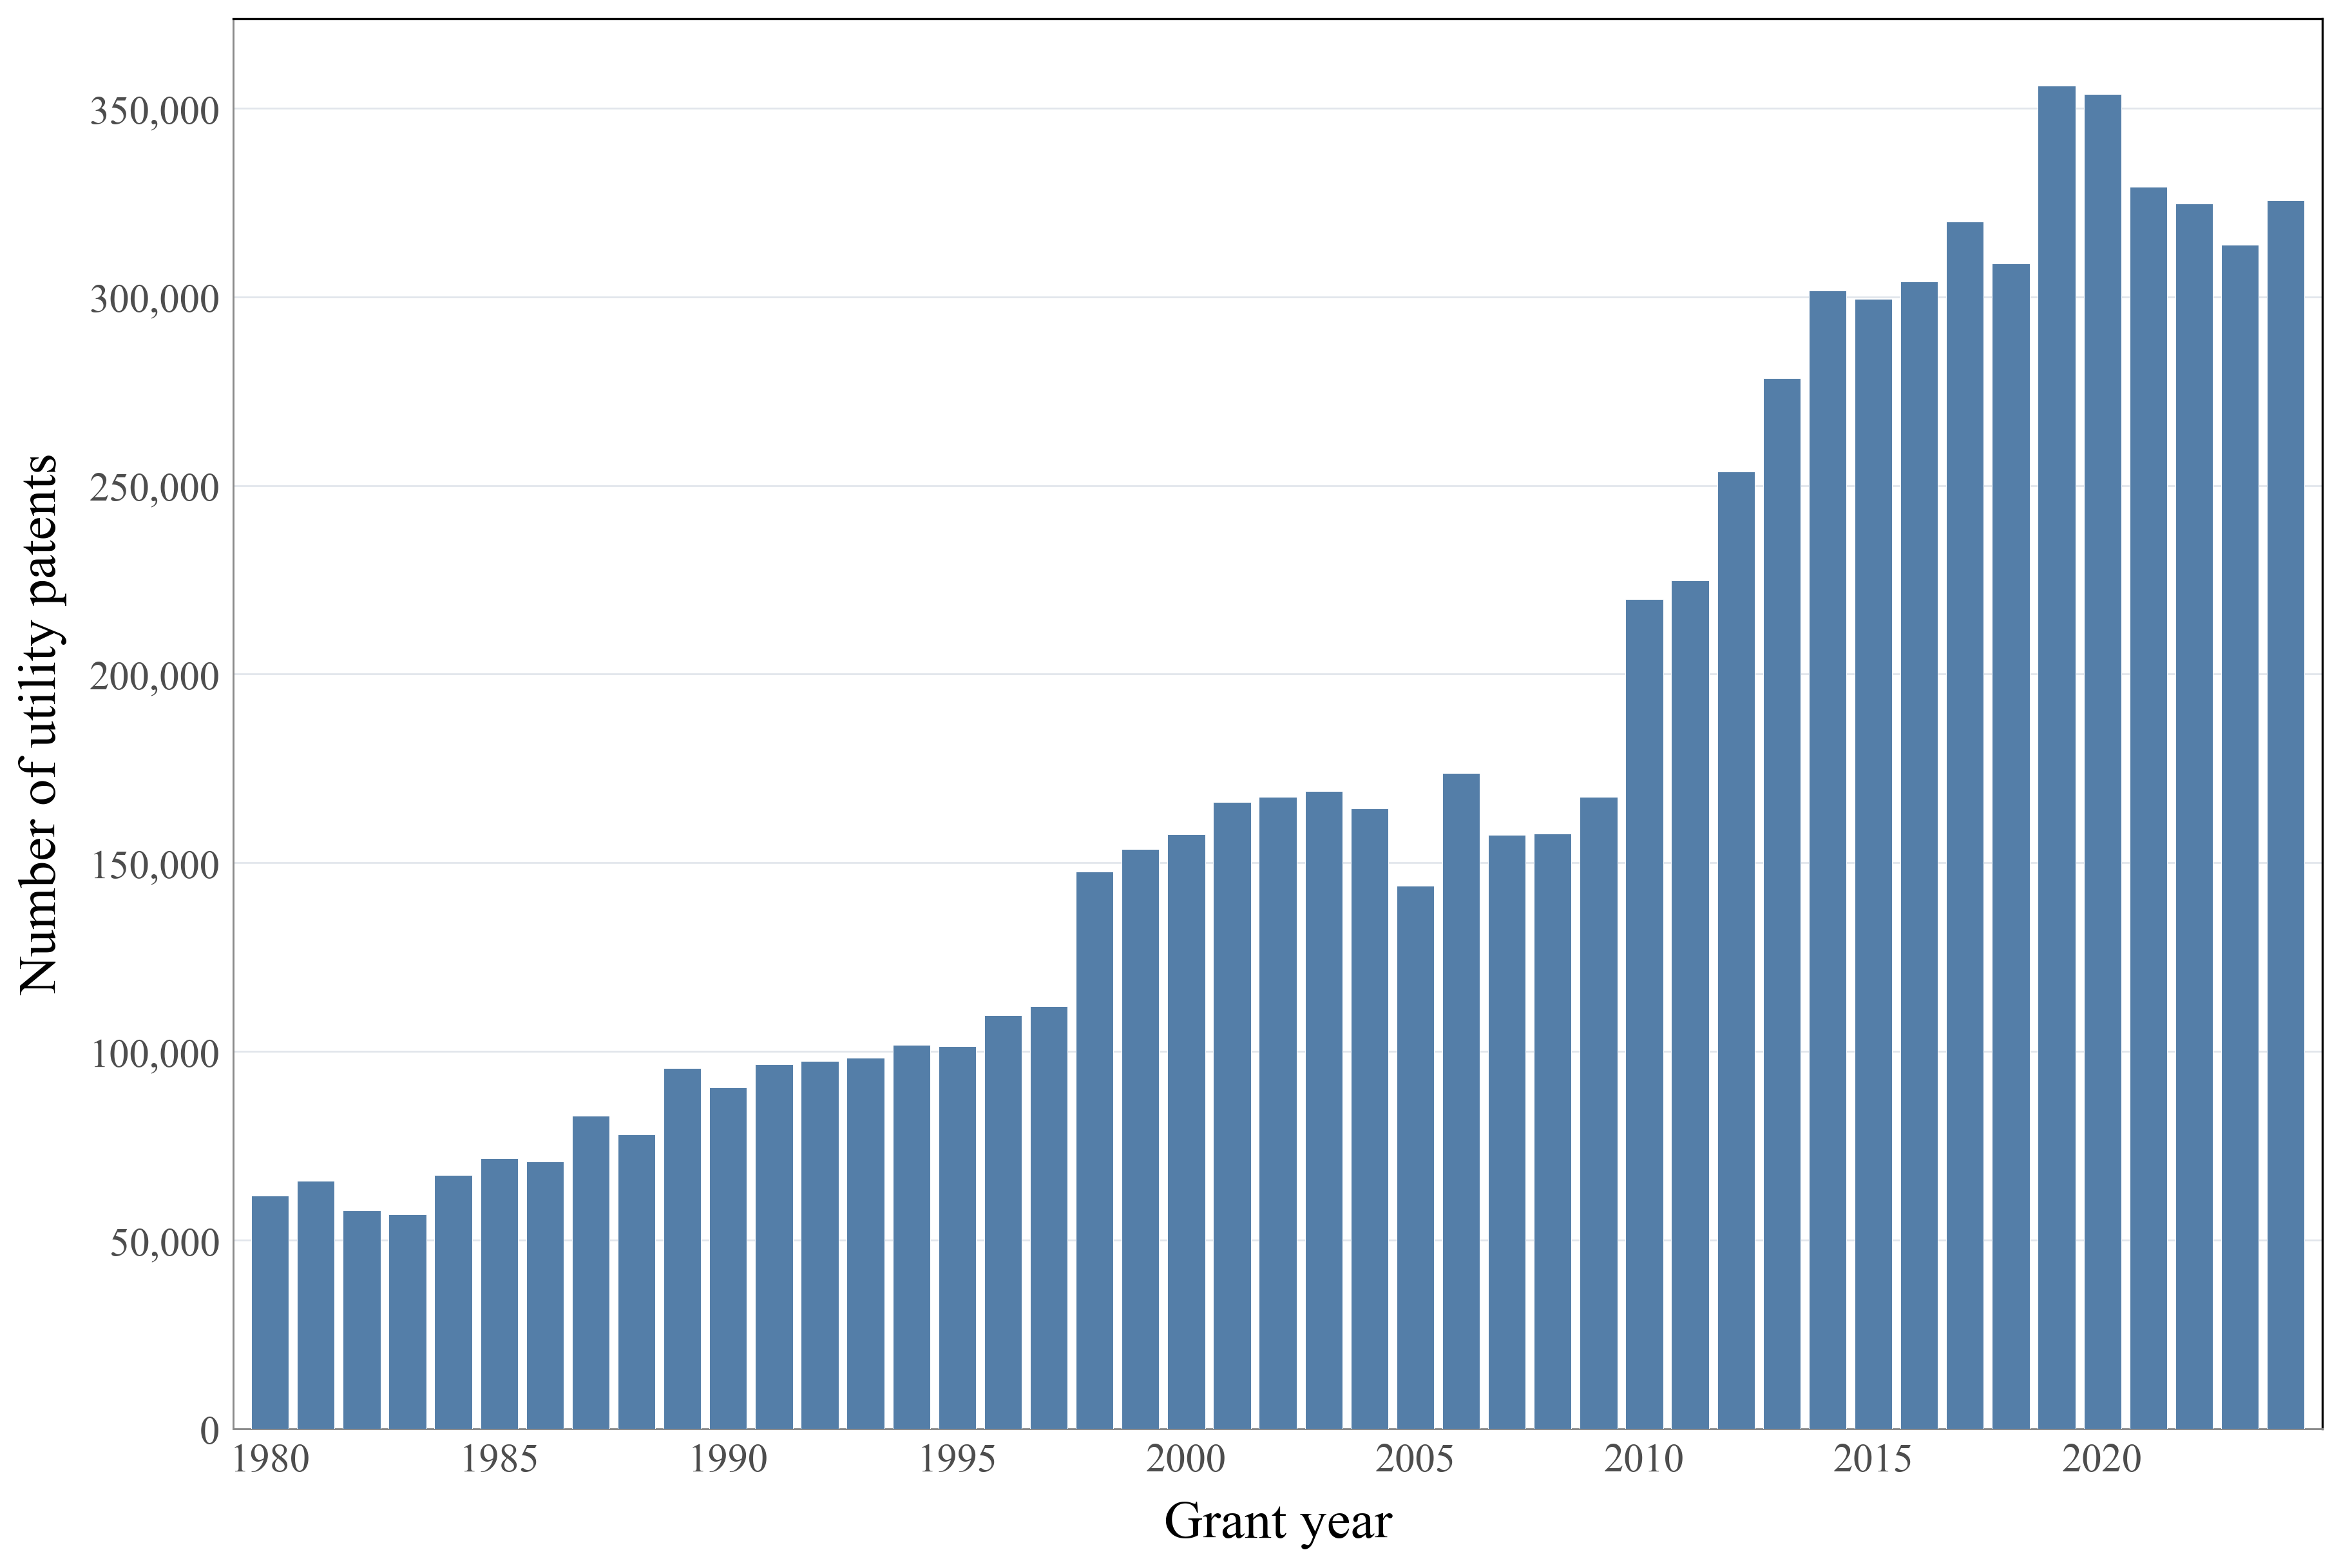

In [12]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# 统计各年份专利数量
year_counts = (
    df_citations_merged
    .dropna(subset=["patent_year"])
    .assign(patent_year=lambda x: x["patent_year"].astype(int))
    .groupby("patent_year")
    .size()
    .sort_index()
)

# 补齐没有专利记录的年份
years = np.arange(year_counts.index.min(),
                  year_counts.index.max() + 1)

year_counts = year_counts.reindex(years, fill_value=0)

fig, ax = plt.subplots(
    figsize=(12, 8),
    dpi=300,
    layout="constrained"
)

# 柱形
bars = ax.bar(
    years,
    year_counts.values,
    width=0.82,
    color="#547EA8",
    edgecolor="white",
    linewidth=0.25,
    zorder=3
)


# 坐标轴
ax.set_xlabel("Grant year", labelpad=8)
ax.set_ylabel("Number of utility patents", labelpad=8)

# 每5年一个刻度
first_tick = int(np.ceil(years.min() / 5) * 5)
ax.set_xticks(np.arange(first_tick, years.max() + 1, 5))
ax.set_xlim(years.min() - 0.8, years.max() + 0.8)

# 千位分隔符
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# 仅保留浅色水平辅助线
ax.grid(
    axis="y",
    color="#D8DDE5",
    linewidth=0.65,
    alpha=0.75,
    zorder=0
)

ax.tick_params(axis="both", length=0, pad=5, colors="#4D4D4D")
ax.spines["left"].set_color("#8A8A8A")
ax.spines["bottom"].set_color("#8A8A8A")
ax.spines["left"].set_linewidth(0.7)
ax.spines["bottom"].set_linewidth(0.7)

# 论文推荐优先保存矢量格式

plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9904\4000513021.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([int(y) for y in ax.get_yticks()], fontsize=10)  # 强制纵坐标为整数


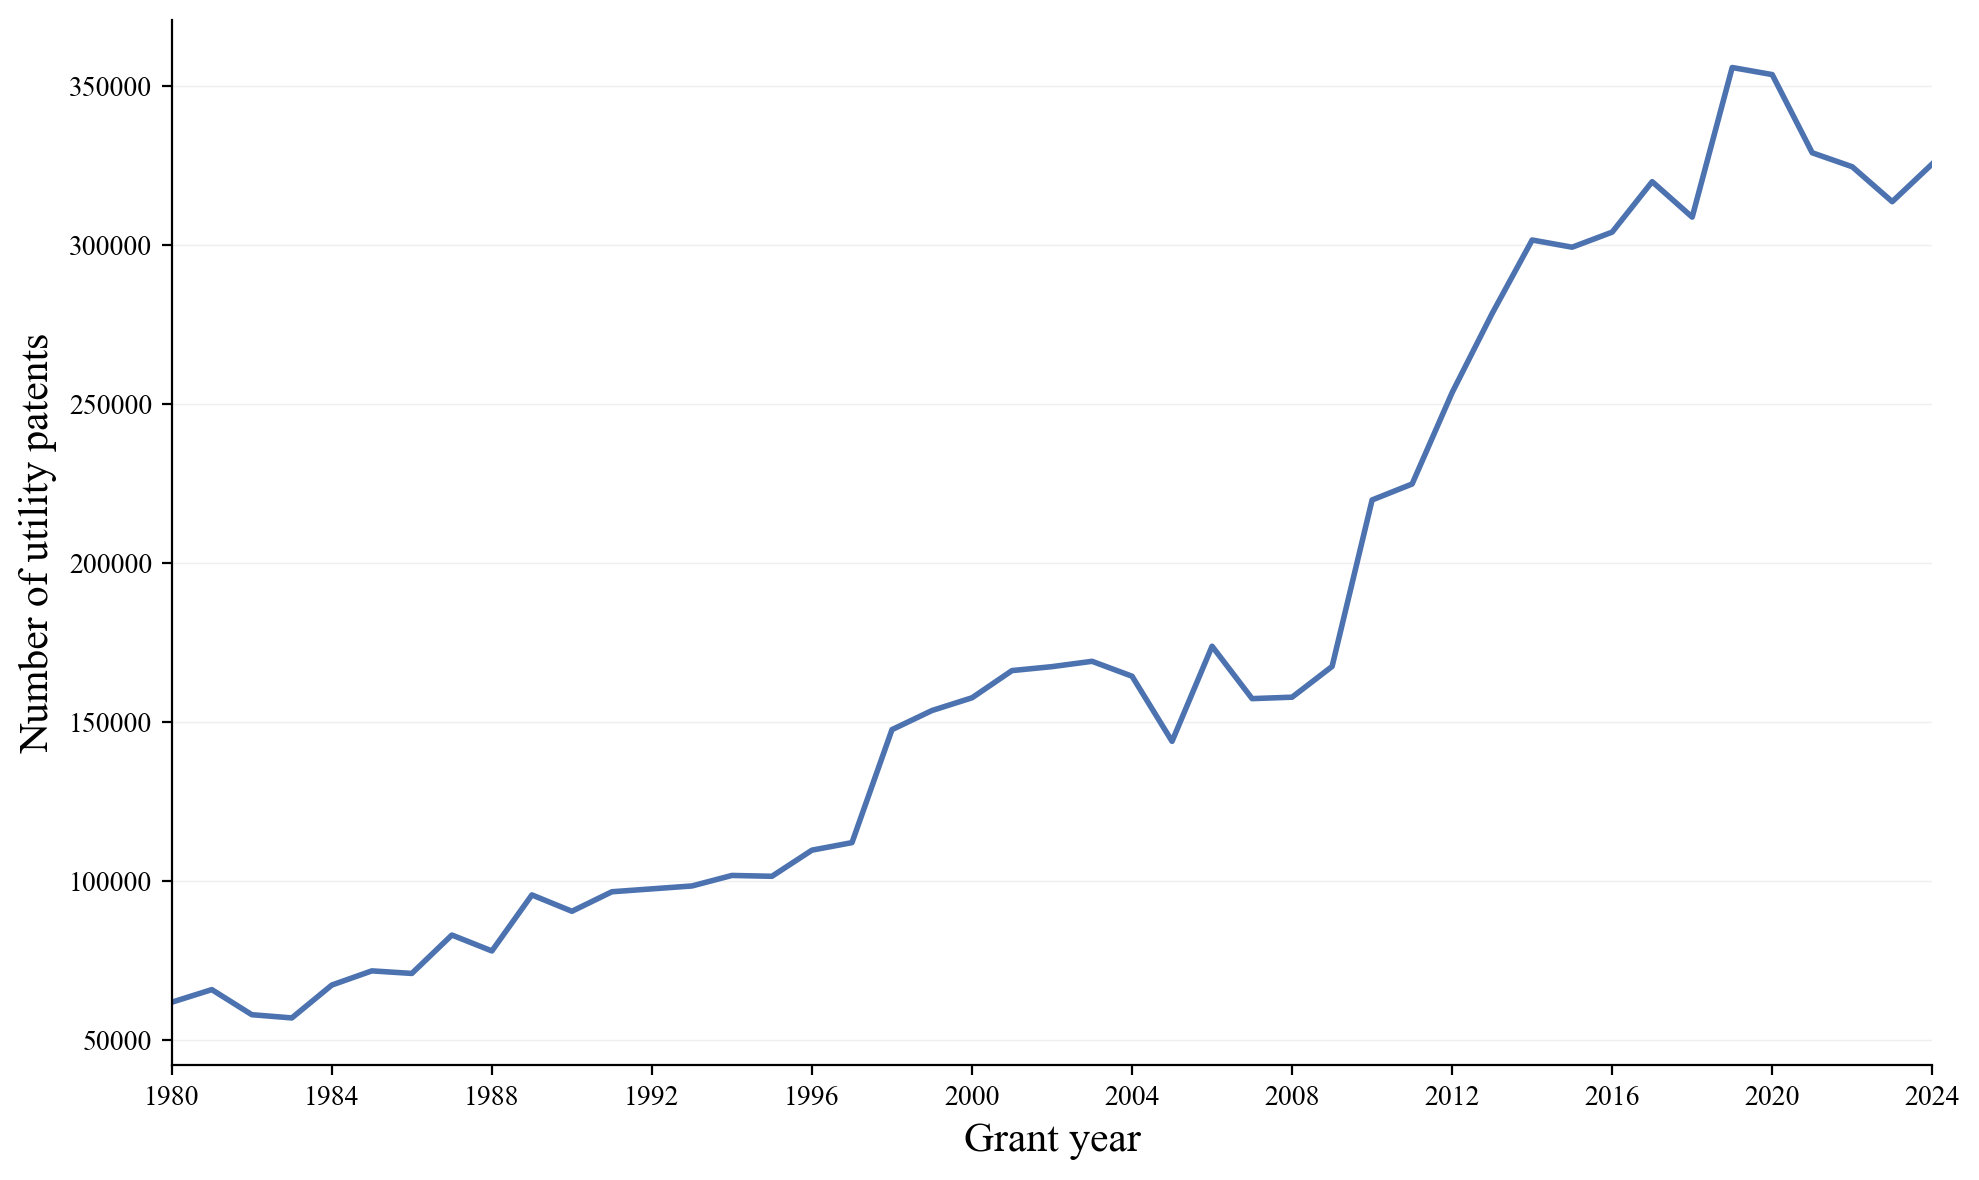

In [13]:
# ------------------------------------------------------------------
# 1. 统计每年专利数量（保持原逻辑不变）
# ------------------------------------------------------------------
year_counts = df_citations_merged.groupby('patent_year').size().sort_index()

# ------------------------------------------------------------------
# 2. 极简折线图（无冗余元素）
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)  # 适中尺寸，不用过高DPI

# 核心折线（仅保留线条，简洁为主）
ax.plot(
    year_counts.index, 
    year_counts.values, 
    color='#4c72b0',  # 经典蓝色，不花哨
    linewidth=2,      # 线条宽度适中
    linestyle='-'     # 简单实线
)

# 解决「首尾空隙」：x轴范围紧贴数据起止年份
ax.set_xlim(year_counts.index.min(), year_counts.index.max())  # 1980和2024直接顶到图边

# 坐标轴设置（简洁明了）
ax.set_xlabel('Grant year', fontsize=15)
ax.set_ylabel('Number of utility patents', fontsize=15)

# 刻度优化（无多余刻度，纵坐标无小数点）
ax.set_xticks(range(1980, 2025, 4))  # 每4年一个刻度，不拥挤
ax.set_xticklabels(range(1980, 2025, 4), fontsize=10)
ax.set_yticklabels([int(y) for y in ax.get_yticks()], fontsize=10)  # 强制纵坐标为整数

# 极简网格（可选，如需辅助读数保留，否则可删除）
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# 去除多余边框（仅保留必要边框，不复杂）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 紧凑布局（避免标签截断）
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9904\1093455572.py:61: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels([f'{int(y)}' for y in plt.gca().get_yticks()], fontsize=10)


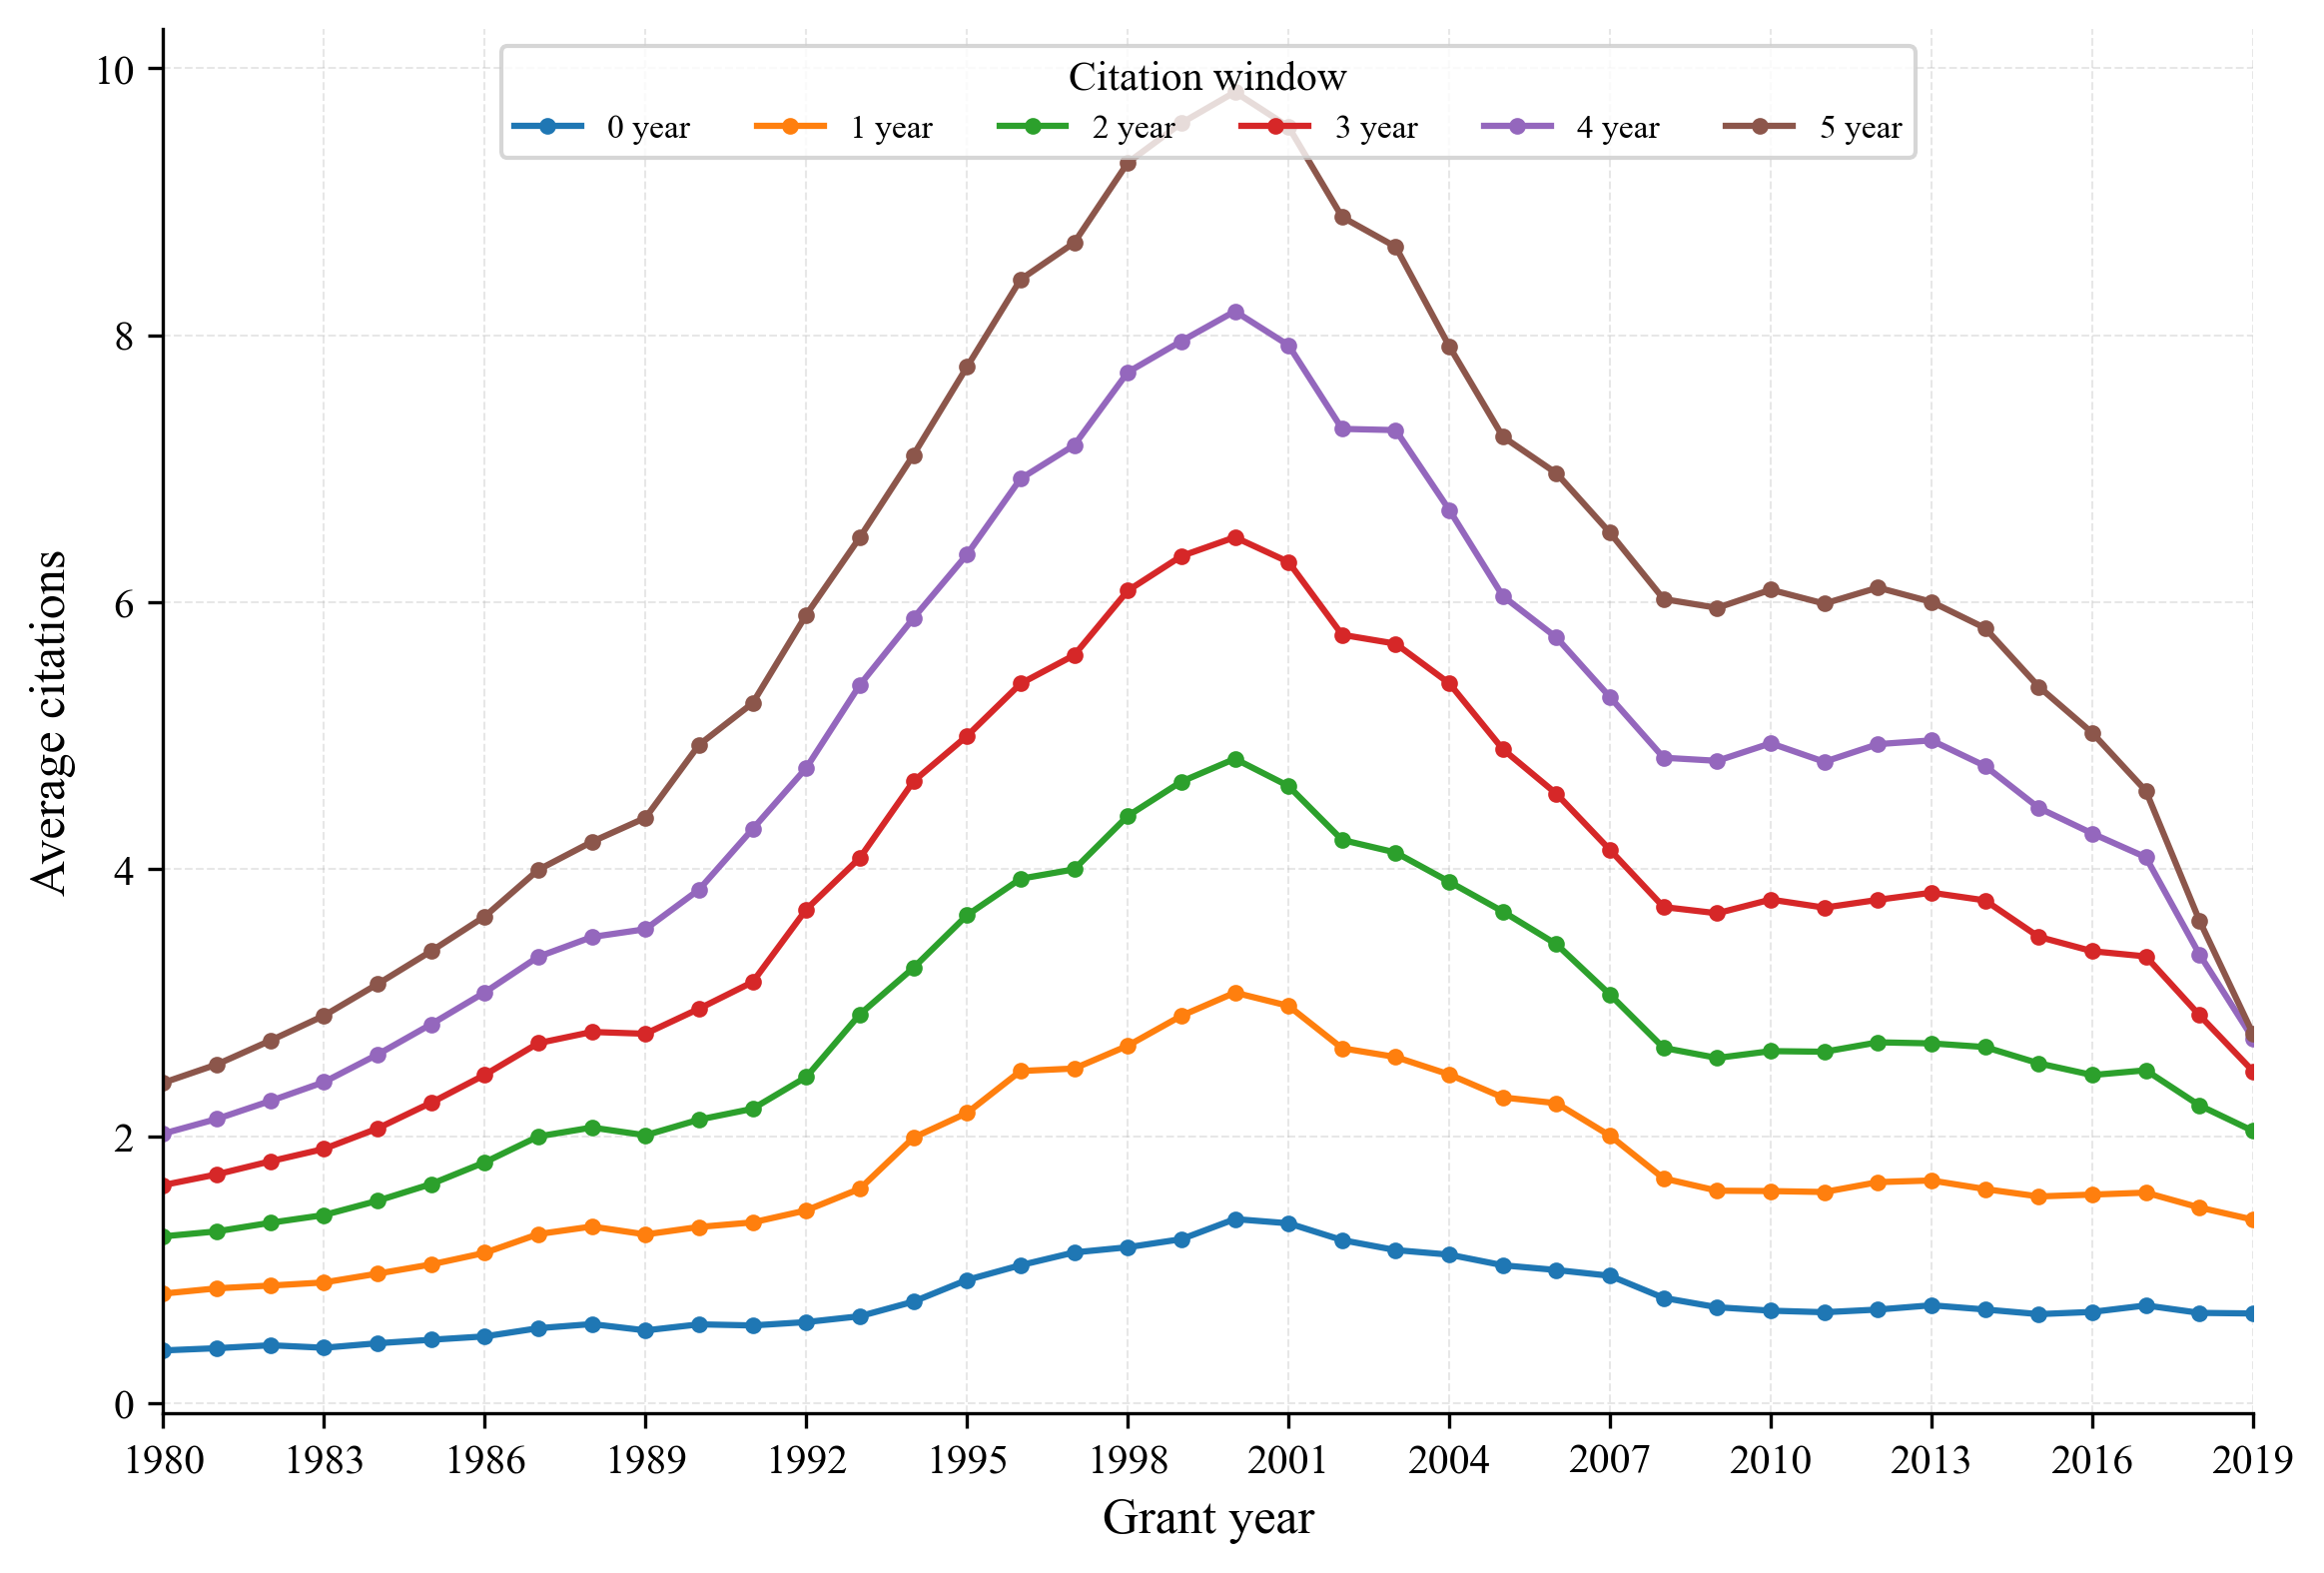

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 基础设置（避免乱码，保持简洁）
plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 只保留 1980–2018 年的 utility 专利
cite_cols = ['cites_0yr', 'cites_1yr', 'cites_2yr',
             'cites_3yr', 'cites_4yr', 'cites_5yr']

# 1. 过滤：patent_year 1980-2018
df_use = df_citations_merged[
    (df_citations_merged['patent_year'] >= 1980) &
    (df_citations_merged['patent_year'] < 2020)
]

# 2. 按授权年份分组，计算各列均值
yearly = (
    df_use.groupby('patent_year')[cite_cols]
          .mean()
          .sort_index()
)

# 3. 画图（优化版）
plt.figure(figsize=(9, 6), dpi=300)

# 绘制折线：优化线条和标记细节，标签替换为 year
for col in cite_cols:
    # 标签替换：cites_0yr → 0 year，更规范美观
    label = col.replace('cites_', '').replace('yr', ' year')
    plt.plot(
        yearly.index, 
        yearly[col], 
        marker='o', 
        markersize=3,  # 标记缩小，避免拥挤
        linewidth=1.5,  # 线条宽度适中
        label=label
    )

# 坐标轴设置：简洁清晰
plt.xlabel('Grant year', fontsize=12)
plt.ylabel('Average citations', fontsize=12)

# 核心优化1：图例居中（在图表正中间）
plt.legend(
    title='Citation window', 
    loc='upper center',
    bbox_to_anchor=(0.5, 1),  # 向下微调，避免遮挡数据
    ncol=6,  # 图例分3列排列，更紧凑
    fontsize=8,
    title_fontsize=10
)

# 核心优化2：x轴紧贴数据，无多余空隙
plt.xlim(yearly.index.min(), yearly.index.max())

# 刻度优化：x轴每4年一个刻度，不拥挤
plt.xticks(range(1980, 2020, 3), fontsize=10)
# 纵坐标无小数点（如需）
plt.gca().set_yticklabels([f'{int(y)}' for y in plt.gca().get_yticks()], fontsize=10)

# 网格优化：浅灰色，不干扰视觉
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)

# 去除多余边框，更简洁
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

##### Step 3.5 每年前5%被引专利

In [16]:
control_variables = pd.read_csv(r'E:\tinierZhao_E_recovery\US-AI-Patents-main\US-AI-Patents-main\patent_control_variable\result\control_variables.csv')

control_variables['patent_id'] = control_variables['patent_id'].astype('str')

In [17]:
control_variables

,patent_id,wipo_kind,num_claims,patent_year,wipo_field_id,inventor_count,ipc_class_count,num_references
0,10000000,B2,20,2018,10,1,2,2
1,10000001,B2,12,2018,29,2,3,6
2,10000002,B2,9,2018,21,4,6,3
3,10000003,B2,18,2018,29,3,7,4
4,10000004,B2,6,2018,29,2,4,2
...,...,...,...,...,...,...,...,...
7469932,9999995,B2,5,2018,29,2,3,6
7469933,9999996,B2,9,2018,23,2,3,4
7469934,9999997,B2,18,2018,26,3,3,14
7469935,9999998,B2,13,2018,29,1,4,1


In [15]:
df_use

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr,patent_year
0,10000000,utility,4,6,7,9,11,11,12,2018
1,10000001,utility,0,0,0,0,0,0,0,2018
2,10000002,utility,0,0,0,0,0,0,0,2018
3,10000003,utility,1,1,2,2,2,2,2,2018
4,10000004,utility,0,0,0,0,0,0,0,2018
...,...,...,...,...,...,...,...,...,...,...
7955817,RE31700,utility,0,0,0,0,0,0,0,1984
7955818,RE31701,utility,0,0,0,0,0,0,0,1984
7955819,RE31704,utility,0,0,0,0,0,0,0,1984
7955820,RE34357,utility,0,0,0,0,0,0,1,1993


In [18]:
df_use = (
    df_use
    .merge(
        control_variables[['patent_id', 'wipo_field_id']],
        left_on='patent_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [20]:
df_use.dropna(inplace=True)

In [21]:
df_use

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr,patent_year,wipo_field_id
0,10000000,utility,4,6,7,9,11,11,12,2018,10.0
1,10000001,utility,0,0,0,0,0,0,0,2018,29.0
2,10000002,utility,0,0,0,0,0,0,0,2018,21.0
3,10000003,utility,1,1,2,2,2,2,2,2018,29.0
4,10000004,utility,0,0,0,0,0,0,0,2018,29.0
...,...,...,...,...,...,...,...,...,...,...,...
6308999,9999995,utility,0,0,0,0,0,0,0,2018,29.0
6309000,9999996,utility,0,0,1,1,1,1,1,2018,23.0
6309001,9999997,utility,0,0,0,0,0,0,0,2018,26.0
6309002,9999998,utility,0,0,0,0,0,0,0,2018,29.0


In [22]:
# 1. 计算每年 × WIPO技术领域内的 95% 分位数
# ----------------------------------------------------------
pct95 = (
    df_use
    .groupby(['patent_year', 'wipo_field_id'])['cites_5yr']
    .quantile(0.95)
    .rename('pct95')
    .reset_index()
)

# 2. 合并回原数据
# ----------------------------------------------------------
df_top5pct = df_use.merge(
    pct95,
    on=['patent_year', 'wipo_field_id'],
    how='left'
)

# 3. 定义高影响专利：在同一年、同一WIPO领域内进入引用数前5%
# ----------------------------------------------------------
df_top5pct['high_impact'] = (
    (df_top5pct['cites_5yr'] >= df_top5pct['pct95']) &
    (df_top5pct['cites_5yr'] > 0)
).astype(int)

In [23]:
df_top5pct

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr,patent_year,wipo_field_id,pct95,high_impact
0,10000000,utility,4,6,7,9,11,11,12,2018,10.0,10.0,1
1,10000001,utility,0,0,0,0,0,0,0,2018,29.0,12.0,0
2,10000002,utility,0,0,0,0,0,0,0,2018,21.0,7.0,0
3,10000003,utility,1,1,2,2,2,2,2,2018,29.0,12.0,0
4,10000004,utility,0,0,0,0,0,0,0,2018,29.0,12.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835227,9999995,utility,0,0,0,0,0,0,0,2018,29.0,12.0,0
5835228,9999996,utility,0,0,1,1,1,1,1,2018,23.0,8.0,0
5835229,9999997,utility,0,0,0,0,0,0,0,2018,26.0,7.0,0
5835230,9999998,utility,0,0,0,0,0,0,0,2018,29.0,12.0,0


In [24]:
df_top5pct['patent_id'] = df_top5pct['patent_id'].astype('str')

In [25]:
df_top5pct.to_csv('./citations_result/df_top5pct.csv',index=False)

In [18]:
df_top1pct = pd.read_csv('./citations_result/df_top1pct.csv')

#### Step 4 分析语义

In [26]:
p2psim = pd.read_csv('../result/p2p_reference.sim.csv')
p2psim.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9904\3748557244.py:1: DtypeWarning: Columns (0,1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  p2psim = pd.read_csv('../result/p2p_reference.sim.csv')


,cited_id,citing_id,sim,cited_by
0,5093563,10000000,0.619,cited by examiner
1,5751830,10000000,0.675,cited by applicant
2,7804268,10000001,0.695,cited by examiner
3,9022767,10000001,0.788,cited by examiner
4,9090016,10000001,0.673,cited by examiner


In [27]:
p2psim['cited_id'] = p2psim['cited_id'].astype('str')
p2psim['citing_id'] = p2psim['citing_id'].astype('str')

In [29]:
p2psim.to_csv('../result/p2p_reference.sim.csv',index=False)

In [28]:
p2psim = (
    p2psim
    .merge(
        df_citations_merged[['patent_id', 'patent_year','cites_5yr']],
        left_on='citing_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [29]:
p2psim.dropna(subset=['cites_5yr'],inplace=True)

In [30]:
p2psim

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,11.0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,0.0
...,...,...,...,...,...,...,...
112275799,4185894,RE34947,0.612,NaN,RE34947,1995.0,0.0
112275800,4368386,RE34947,0.590,NaN,RE34947,1995.0,0.0
112275801,4481531,RE34947,0.533,NaN,RE34947,1995.0,0.0
112275802,4920417,RE34947,0.822,NaN,RE34947,1995.0,0.0


In [35]:
top5_patent_ids = df_top5pct.loc[
    df_top5pct['high_impact'] == 1,
    'patent_id'
]

p2psim_top = p2psim.assign(
    is_top=p2psim['cited_id'].isin(top5_patent_ids).astype(int)
)

In [36]:
p2psim_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,11.0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
112275799,4185894,RE34947,0.612,NaN,RE34947,1995.0,0.0,0
112275800,4368386,RE34947,0.590,NaN,RE34947,1995.0,0.0,0
112275801,4481531,RE34947,0.533,NaN,RE34947,1995.0,0.0,1
112275802,4920417,RE34947,0.822,NaN,RE34947,1995.0,0.0,0


In [37]:
p2psim_top = p2psim_top[(p2psim_top['sim'] < 0.999)]
p2psim_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,11.0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
112275799,4185894,RE34947,0.612,NaN,RE34947,1995.0,0.0,0
112275800,4368386,RE34947,0.590,NaN,RE34947,1995.0,0.0,0
112275801,4481531,RE34947,0.533,NaN,RE34947,1995.0,0.0,1
112275802,4920417,RE34947,0.822,NaN,RE34947,1995.0,0.0,0


In [38]:
# 保存
p2psim_top.to_csv('./citations_result/p2psim_top_0707.csv',index=False)

In [7]:
p2psim_top = pd.read_csv('./citations_result/p2psim_top.csv')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_316\3877586799.py:1: DtypeWarning: Columns (0,1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  p2psim_top = pd.read_csv('./citations_result/p2psim_top.csv')


In [39]:
p2psim_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,11.0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
112275799,4185894,RE34947,0.612,NaN,RE34947,1995.0,0.0,0
112275800,4368386,RE34947,0.590,NaN,RE34947,1995.0,0.0,0
112275801,4481531,RE34947,0.533,NaN,RE34947,1995.0,0.0,1
112275802,4920417,RE34947,0.822,NaN,RE34947,1995.0,0.0,0


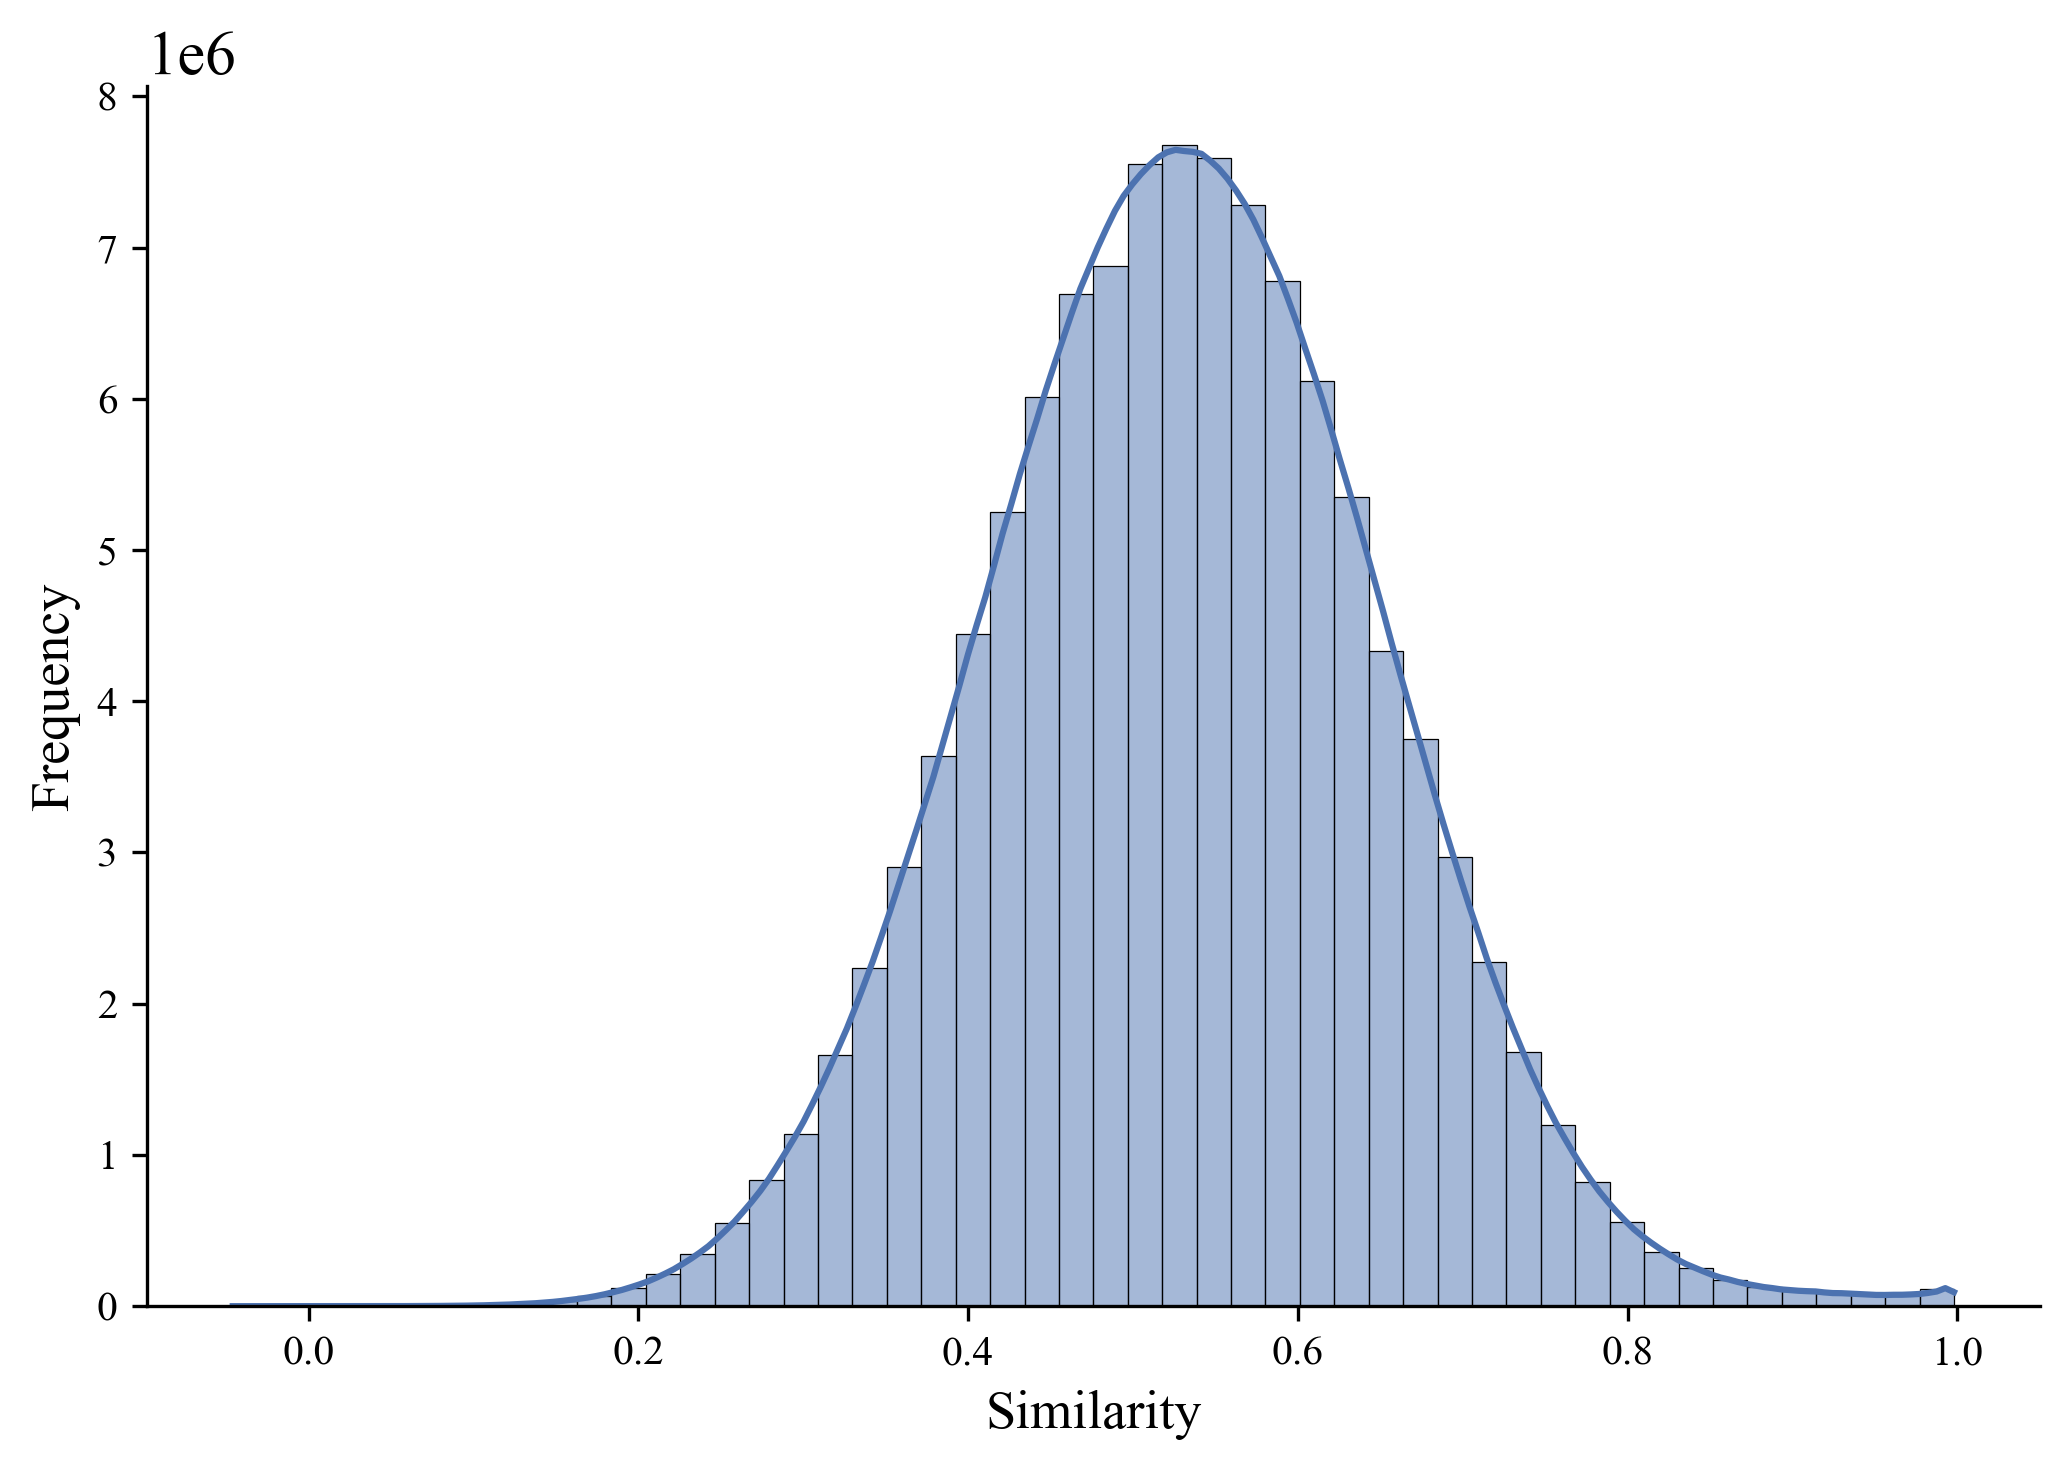

In [29]:
import seaborn as sns

# --------------------------
plt.figure(figsize=(7,5), dpi=300)
# 关键：用ax接收绘图对象，后续修改都靠它
ax = sns.histplot(p2psim_top['sim'], bins=50, kde=True, color='#4c72b0', edgecolor='k', lw=0.3)

# 2. 修改X/Y轴标签字体（大小、加粗、字体）
ax.set_xlabel('Similarity', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)

# 3. 修改X/Y轴刻度字体（大小、字体）
ax.tick_params(axis='x', labelsize=10,)  # X轴刻度
ax.tick_params(axis='y', labelsize=10, )  # Y轴刻度

plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

In [30]:
# 先确保 category 列干净
p2psim_top['cited_by'] = p2psim_top['cited_by'].str.lower().str.strip()

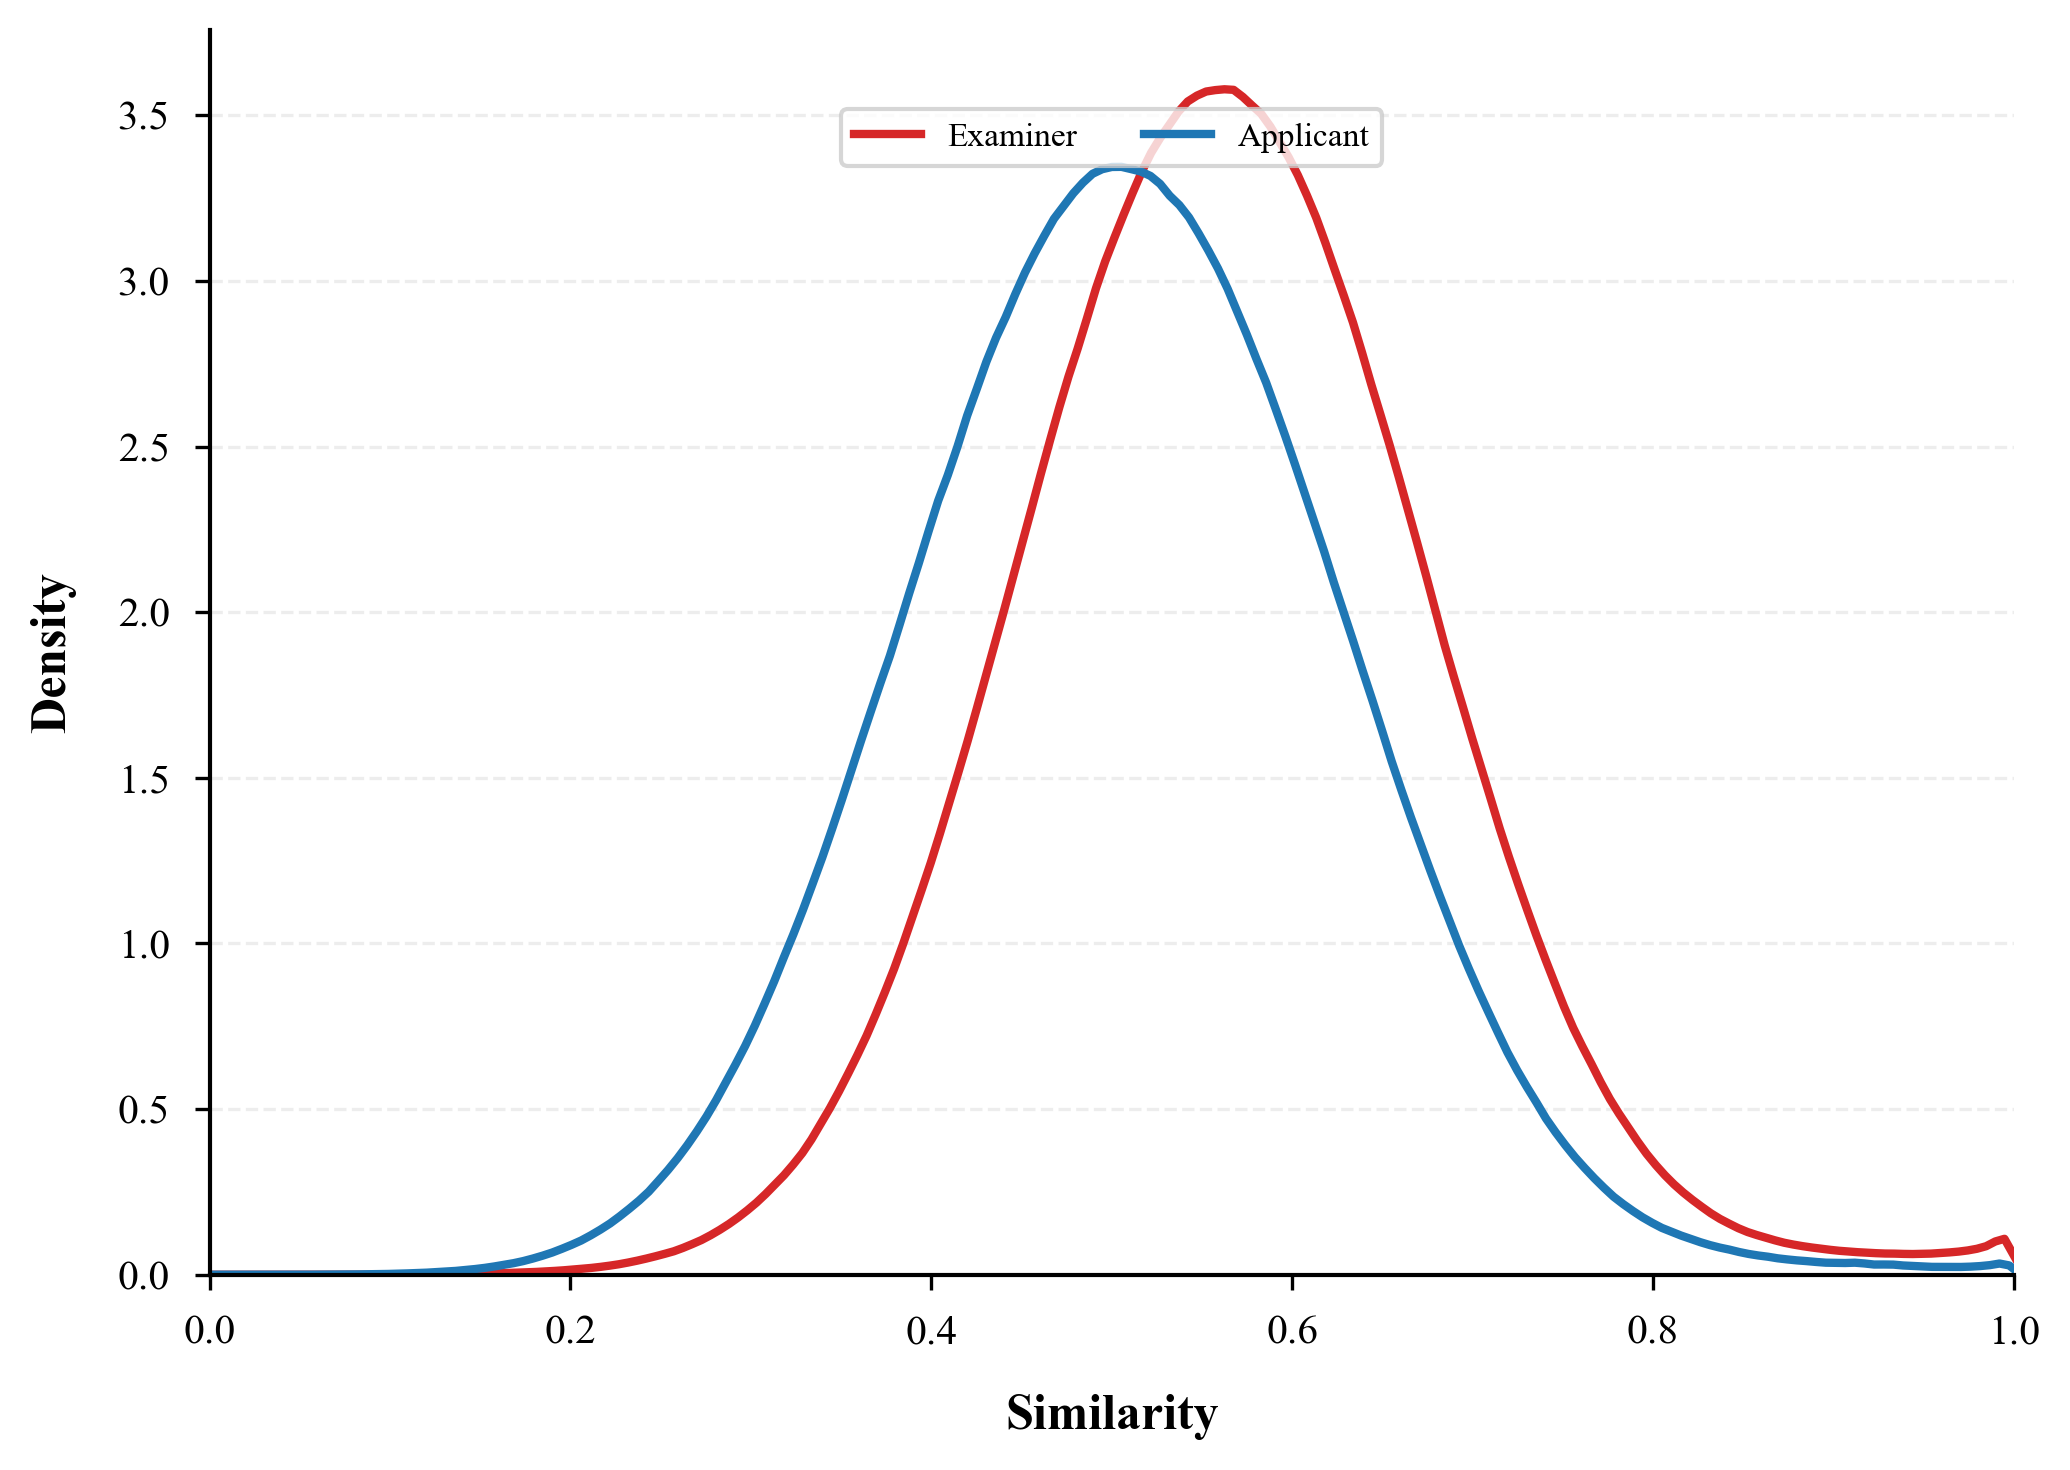

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

sns.kdeplot(
    data=p2psim_top[p2psim_top['cited_by'] == 'cited by examiner'],
    x='sim',
    label='Examiner',
    color='#d62728',   # 红色
    linewidth=2
)

sns.kdeplot(
    data=p2psim_top[p2psim_top['cited_by'] == 'cited by applicant'],
    x='sim',
    label='Applicant',
    color='#1f77b4',   # 蓝色
    linewidth=2
)

# 核心优化1：图例居中（在图表正中间）
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),  # 向下微调，避免遮挡数据
    ncol=2,  # 图例分3列排列，更紧凑
    fontsize=8,
)

# --------------------------
# 6. 优化坐标轴（标签加粗、刻度统一、添加精准网格）
# --------------------------
# 轴标签（加粗+放大，提升可读性）
ax.set_xlabel('Similarity', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

# 轴刻度（统一字号，避免模糊）
ax.tick_params(axis='x', labelsize=10, pad=6)  # X轴刻度+内边距
ax.tick_params(axis='y', labelsize=10, pad=6)  # Y轴刻度+内边距

# 添加精准网格（仅Y轴+虚线，不干扰曲线）
ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8, color='#DDDDDD')

# 精简边框（隐藏顶部+右侧边框，更简洁）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 保留的边框加粗（提升轮廓感）
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# 优化X轴范围（假设相似度是0-1，针对性调整，无数据空白区减少）
ax.set_xlim(0, 1)  # 若你的相似度范围不是0-1，注释此行即可

# --------------------------
# 7. 最终调整+显示（避免冗余，释放内存）
# --------------------------
plt.tight_layout()  # 自动调整布局，防止标签截断
plt.show()

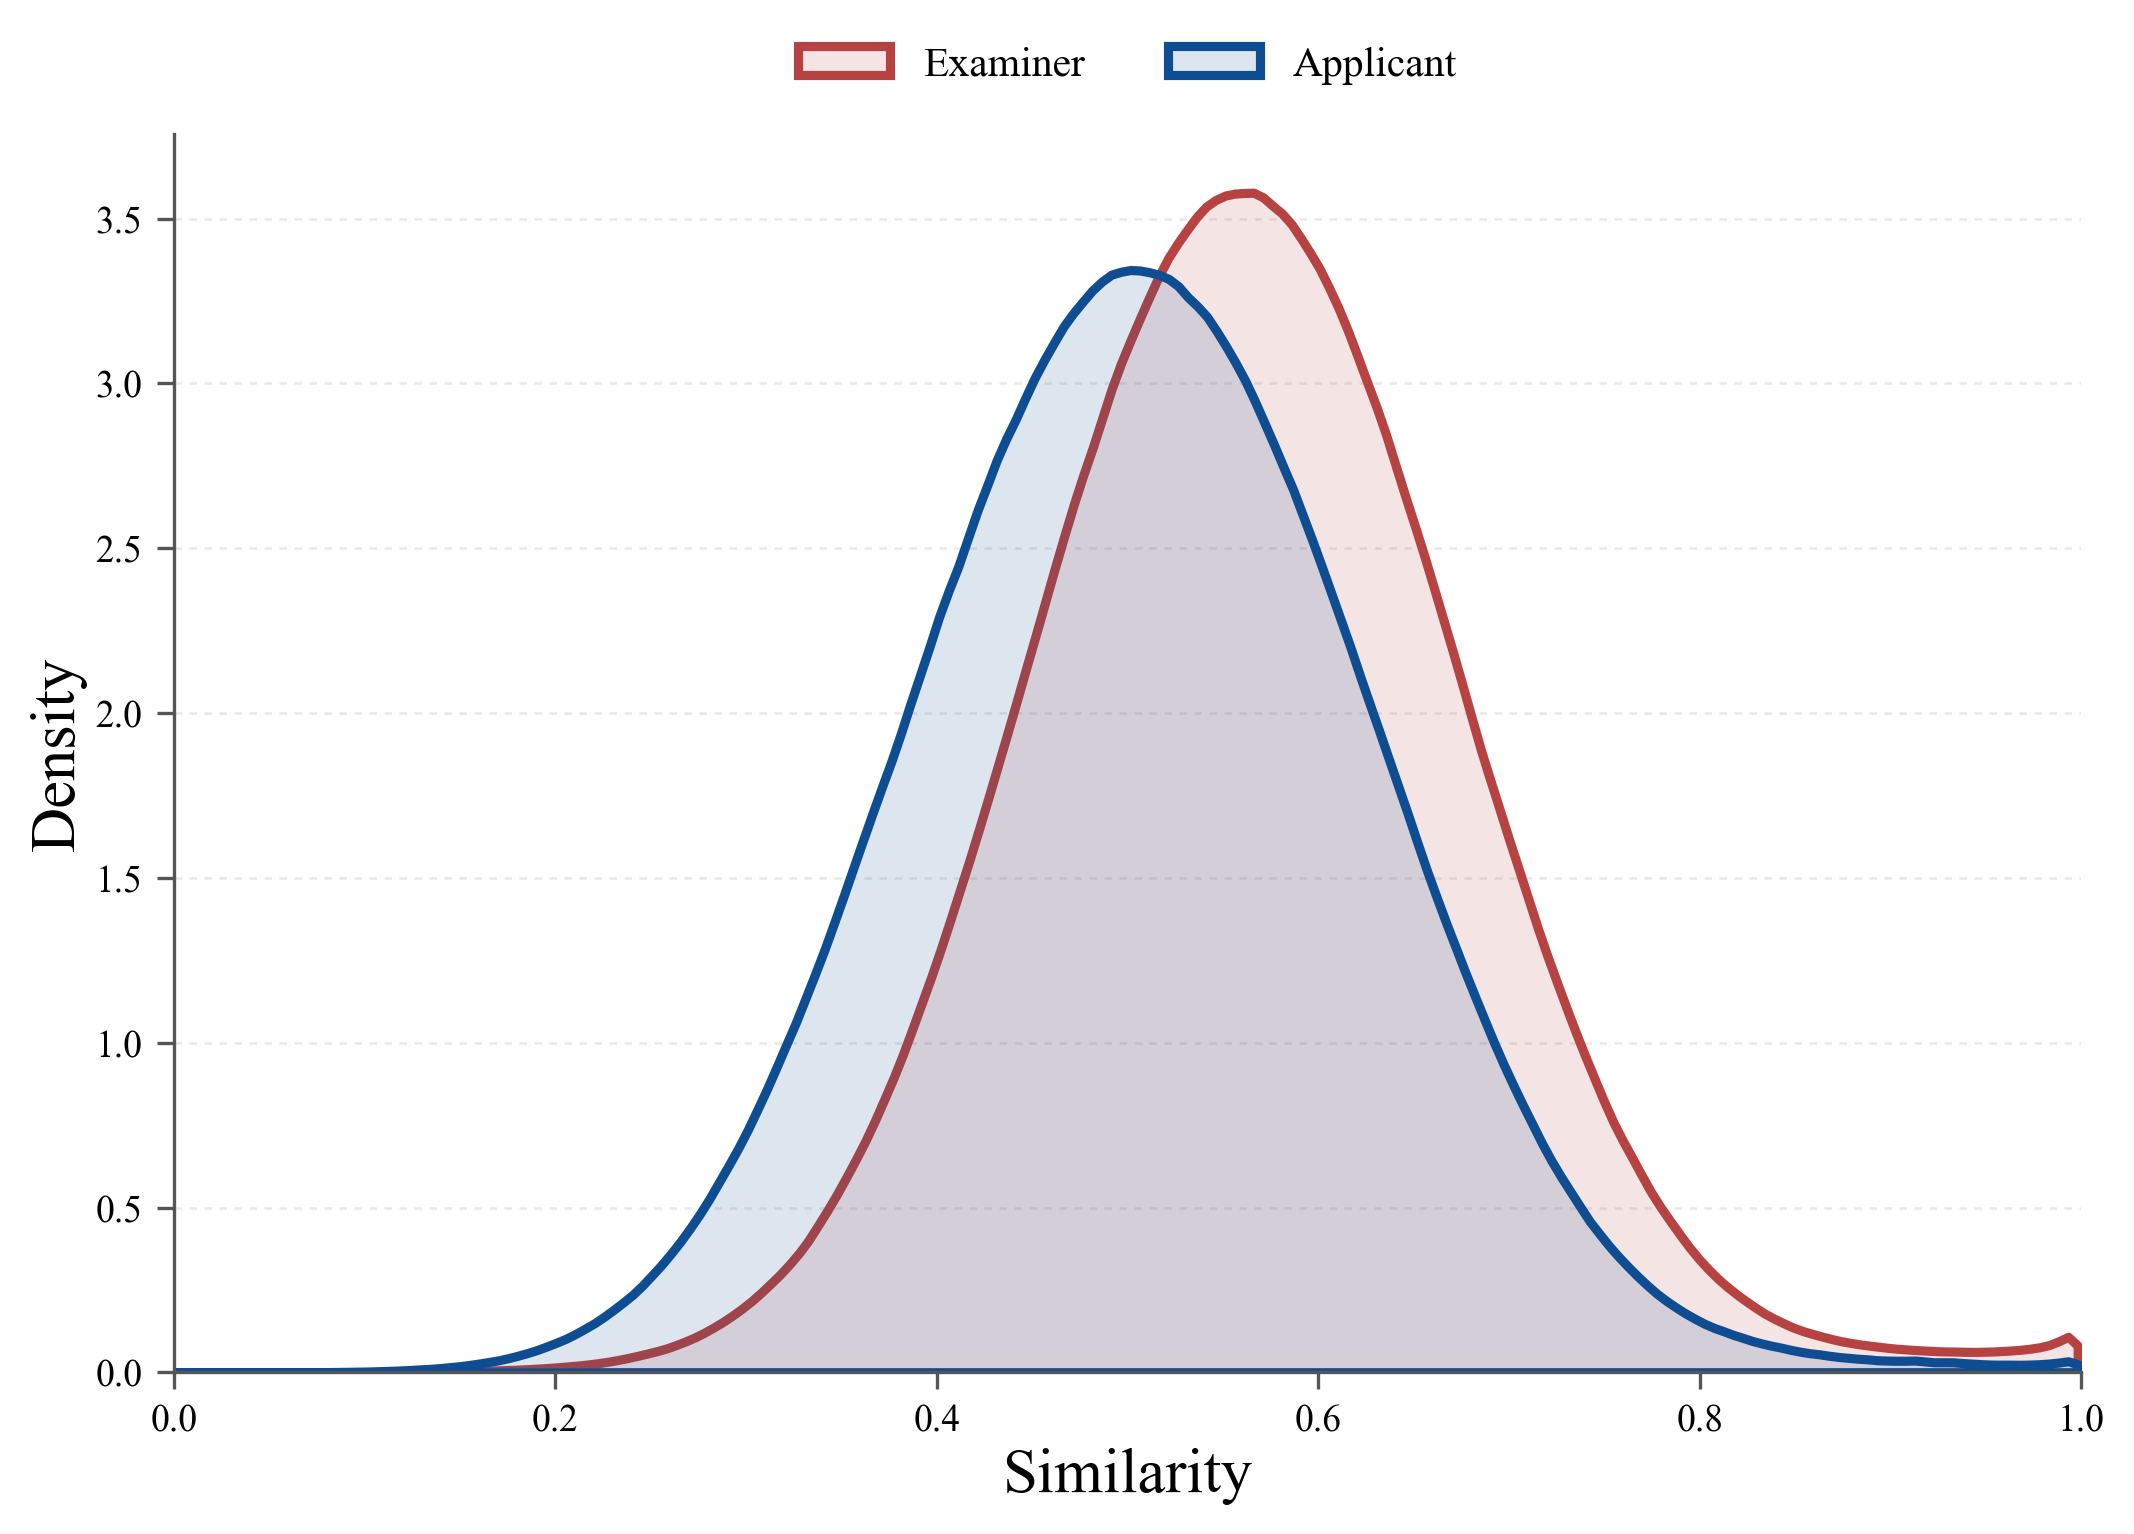

In [43]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt


examiner = (
    p2psim_top.loc[
        p2psim_top["cited_by"].eq("cited by examiner"), "sim"
    ]
    .dropna()
)

applicant = (
    p2psim_top.loc[
        p2psim_top["cited_by"].eq("cited by applicant"), "sim"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300,
    constrained_layout=True
)

# Examiner
sns.kdeplot(
    x=examiner,
    ax=ax,
    label="Examiner",
    color="#B64342",
    linewidth=2.2,
    fill=True,
    alpha=0.14,
    bw_adjust=1.05,
    cut=0,             # 防止密度曲线超出数据边界
    clip=(0, 1),
    warn_singular=False
)

# Applicant
sns.kdeplot(
    x=applicant,
    ax=ax,
    label="Applicant",
    color="#0F4D92",
    linewidth=2.2,
    fill=True,
    alpha=0.14,
    bw_adjust=1.05,
    cut=0,
    clip=(0, 1),
    warn_singular=False
)

# 坐标轴
ax.set(
    xlabel="Similarity",
    ylabel="Density",
    xlim=(0, 1)
)
ax.set_ylim(bottom=0)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax.set_xlabel("Similarity", fontsize=15, labelpad=2)
ax.set_ylabel("Density", fontsize=15, labelpad=2)

ax.tick_params(
    axis="both",
    labelsize=9,
    length=4,
    width=0.8,
    color="#555555"
)

# 非常淡的水平辅助线
ax.set_axisbelow(True)
ax.grid(
    axis="y",
    linestyle=(0, (3, 3)),
    linewidth=0.6,
    color="#D8D8D8",
    alpha=0.55
)
ax.grid(axis="x", visible=False)

# 简化边框
sns.despine(ax=ax)
ax.spines["left"].set_color("#555555")
ax.spines["bottom"].set_color("#555555")

# 图例放在上方，避免遮挡曲线
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=2.2,
    columnspacing=2.0
)

plt.show()

In [61]:
p2psim_top.to_csv('./p2psim_top.csv',index=False)

#### Step 4 加载颠覆性指数

In [19]:
df_di = pd.read_csv('./citations_result/CD5_index.csv')

#### Step 5 直接加载p2psim_top

In [20]:
p2psim_top = pd.read_csv('./citations_result/p2psim_top.csv')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10076\3877586799.py:1: DtypeWarning: Columns (0,1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  p2psim_top = pd.read_csv('./citations_result/p2psim_top.csv')


In [21]:
p2psim_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,11.0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
110360780,4185894,RE34947,0.612,NaN,RE34947,1995.0,0.0,0
110360781,4368386,RE34947,0.590,NaN,RE34947,1995.0,0.0,0
110360782,4481531,RE34947,0.533,NaN,RE34947,1995.0,0.0,0
110360783,4920417,RE34947,0.822,NaN,RE34947,1995.0,0.0,0


##### 分析第一相似度

In [40]:
p2psim_top_max_sim = p2psim_top.loc[p2psim_top.groupby("citing_id")["sim"].idxmax()].reset_index(drop=True)

In [44]:
p2psim_top_max_sim.to_csv('./citations_result/p2psim_top_max_sim_707.csv',index=False)

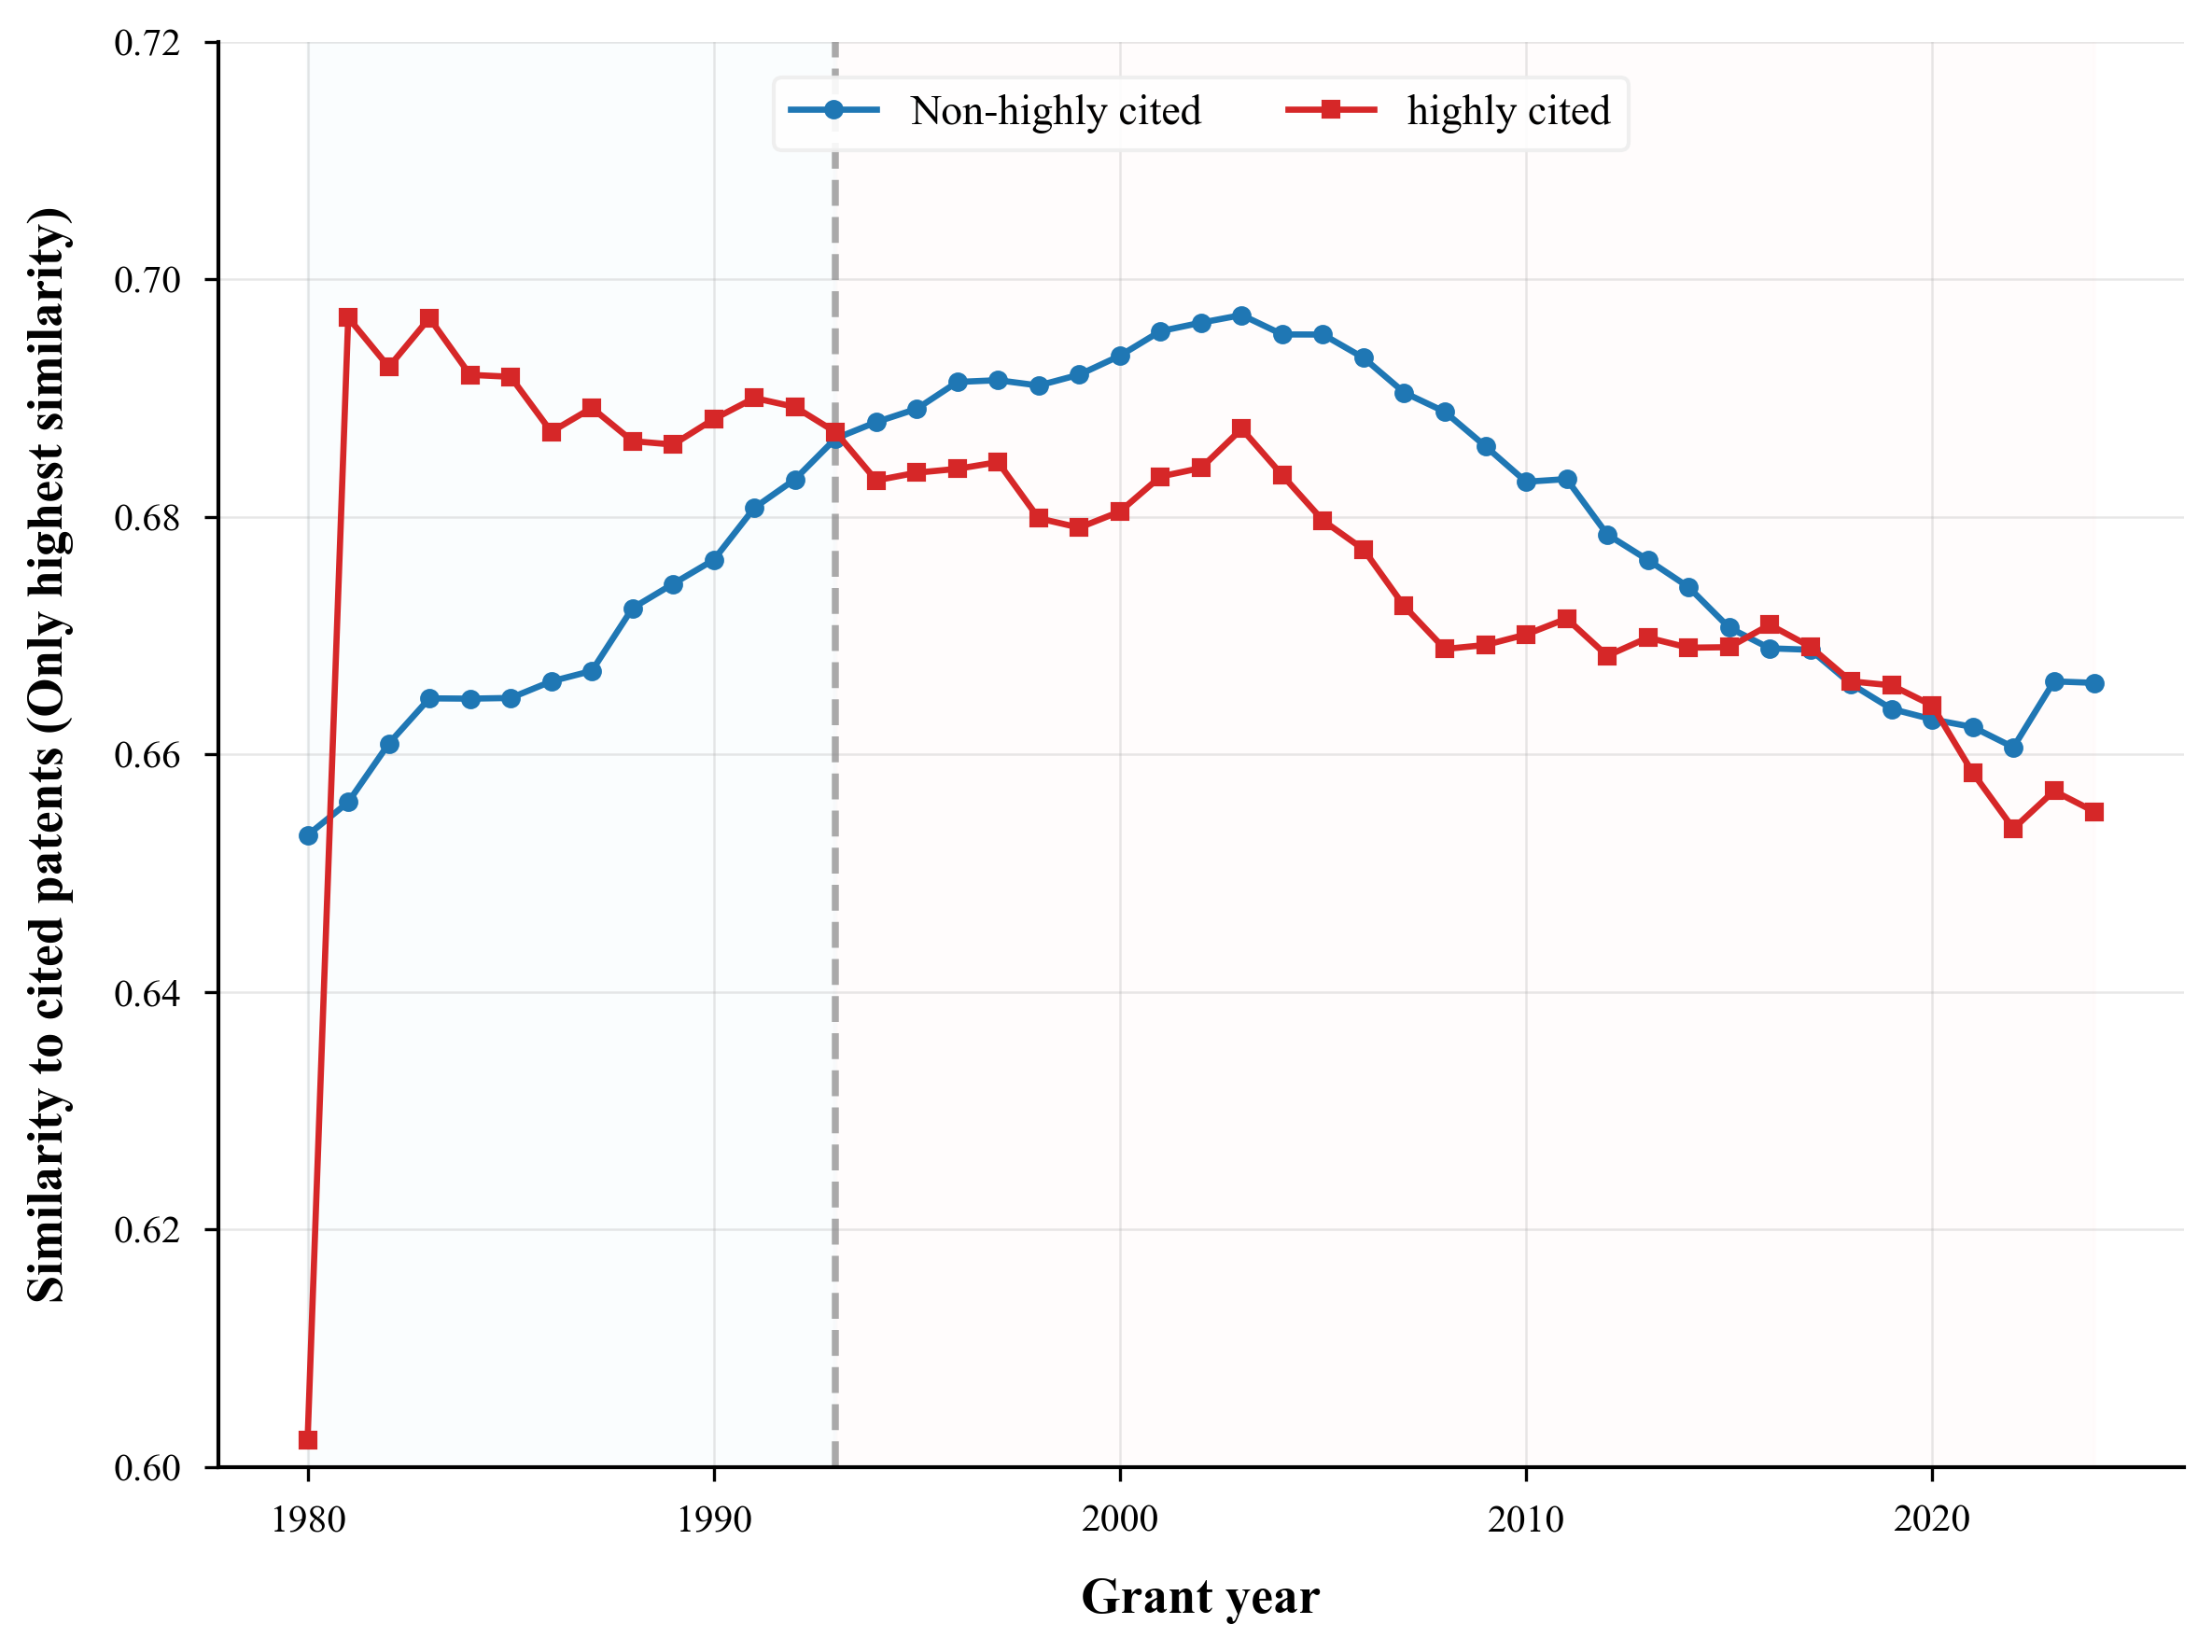

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) 按 is_top 分组，取每年平均 similarity
year_sim = (
    p2psim_top_max_sim   # 这个地方也可以调整为 max sim 
    .query("1980 <= patent_year <= 2024")
    .assign(group=lambda x: np.where(x['is_top'] == 0, 'non-top', 'top'))
    .groupby(['patent_year', 'group'])['sim']
    .mean()
    .unstack('group')          # pivot 成列
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300) 

# --------------------------
# 关键修复：fill_between 参数修正（ymin→y2，ymax→y1）
# --------------------------
# 左侧填充（1980-1993）：浅蓝色，低透明度
ax.fill_between(
    x=year_sim.index[year_sim.index <= 1993],  # x范围：1993及之前
    y2=0,  # 填充下限（原ymin，对应fill_between的y2参数）
    y1=year_sim.max().max() * 1.05,  # 填充上限（原ymax，对应fill_between的y1参数）
    color='#E8F4FD',  # 浅蓝（柔和不刺眼）
    alpha=0.18,  # 低透明度，不干扰折线
    zorder=0  # 图层优先级：0（最下层）
)

# 右侧填充（1993-2024）：浅红色，低透明度
ax.fill_between(
    x=year_sim.index[year_sim.index >= 1993],  # x范围：1993及之后
    y2=0,  # 填充下限
    y1=year_sim.max().max() * 1.05,  # 填充上限
    color='#FFF2F2',  # 浅红（与左侧区分）
    alpha=0.18,
    zorder=0
)

ax.plot(
    year_sim.index, 
    year_sim['non-top'],
    color='#1f77b4', 
    marker='o',
    lw=1.6, 
    ms=4, 
    label='Non-highly cited',
    zorder=3  # 折线在最上层
)

ax.plot(
    year_sim.index, 
    year_sim['top'],
    color='#d62728', 
    marker='s',
    lw=1.6, 
    ms=4, 
    label='highly cited',
    zorder=3  # 折线在最上层
)

# --------------------------
# 1993年垂直分界线（保持不变）
# --------------------------
ax.axvline(
    x=1993, 
    color='#888888',  # 中灰色
    linestyle='--',  # 虚线
    linewidth=1.8,
    alpha=0.7,
    zorder=1  # 分界线在填充之上、折线之下
)

# --------------------------
# 原有美化优化（保持不变）
# --------------------------
ax.set_xlabel('Grant year', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Similarity to cited patents (Only highest similarity)', fontsize=13, fontweight='bold', labelpad=10)

# 网格优化
ax.grid(alpha=0.3, lw=0.6, zorder=1)

# 精简边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# 图例优化
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='#EEEEEE',
)

# 刻度优化
ax.tick_params(axis='x', labelsize=10, pad=6)
ax.tick_params(axis='y', labelsize=10, pad=6)
ax.set_ylim(0.6,0.72)

ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# 释放内存
plt.close('all')

##### 引用普通专利和top专利的相似度变化趋势

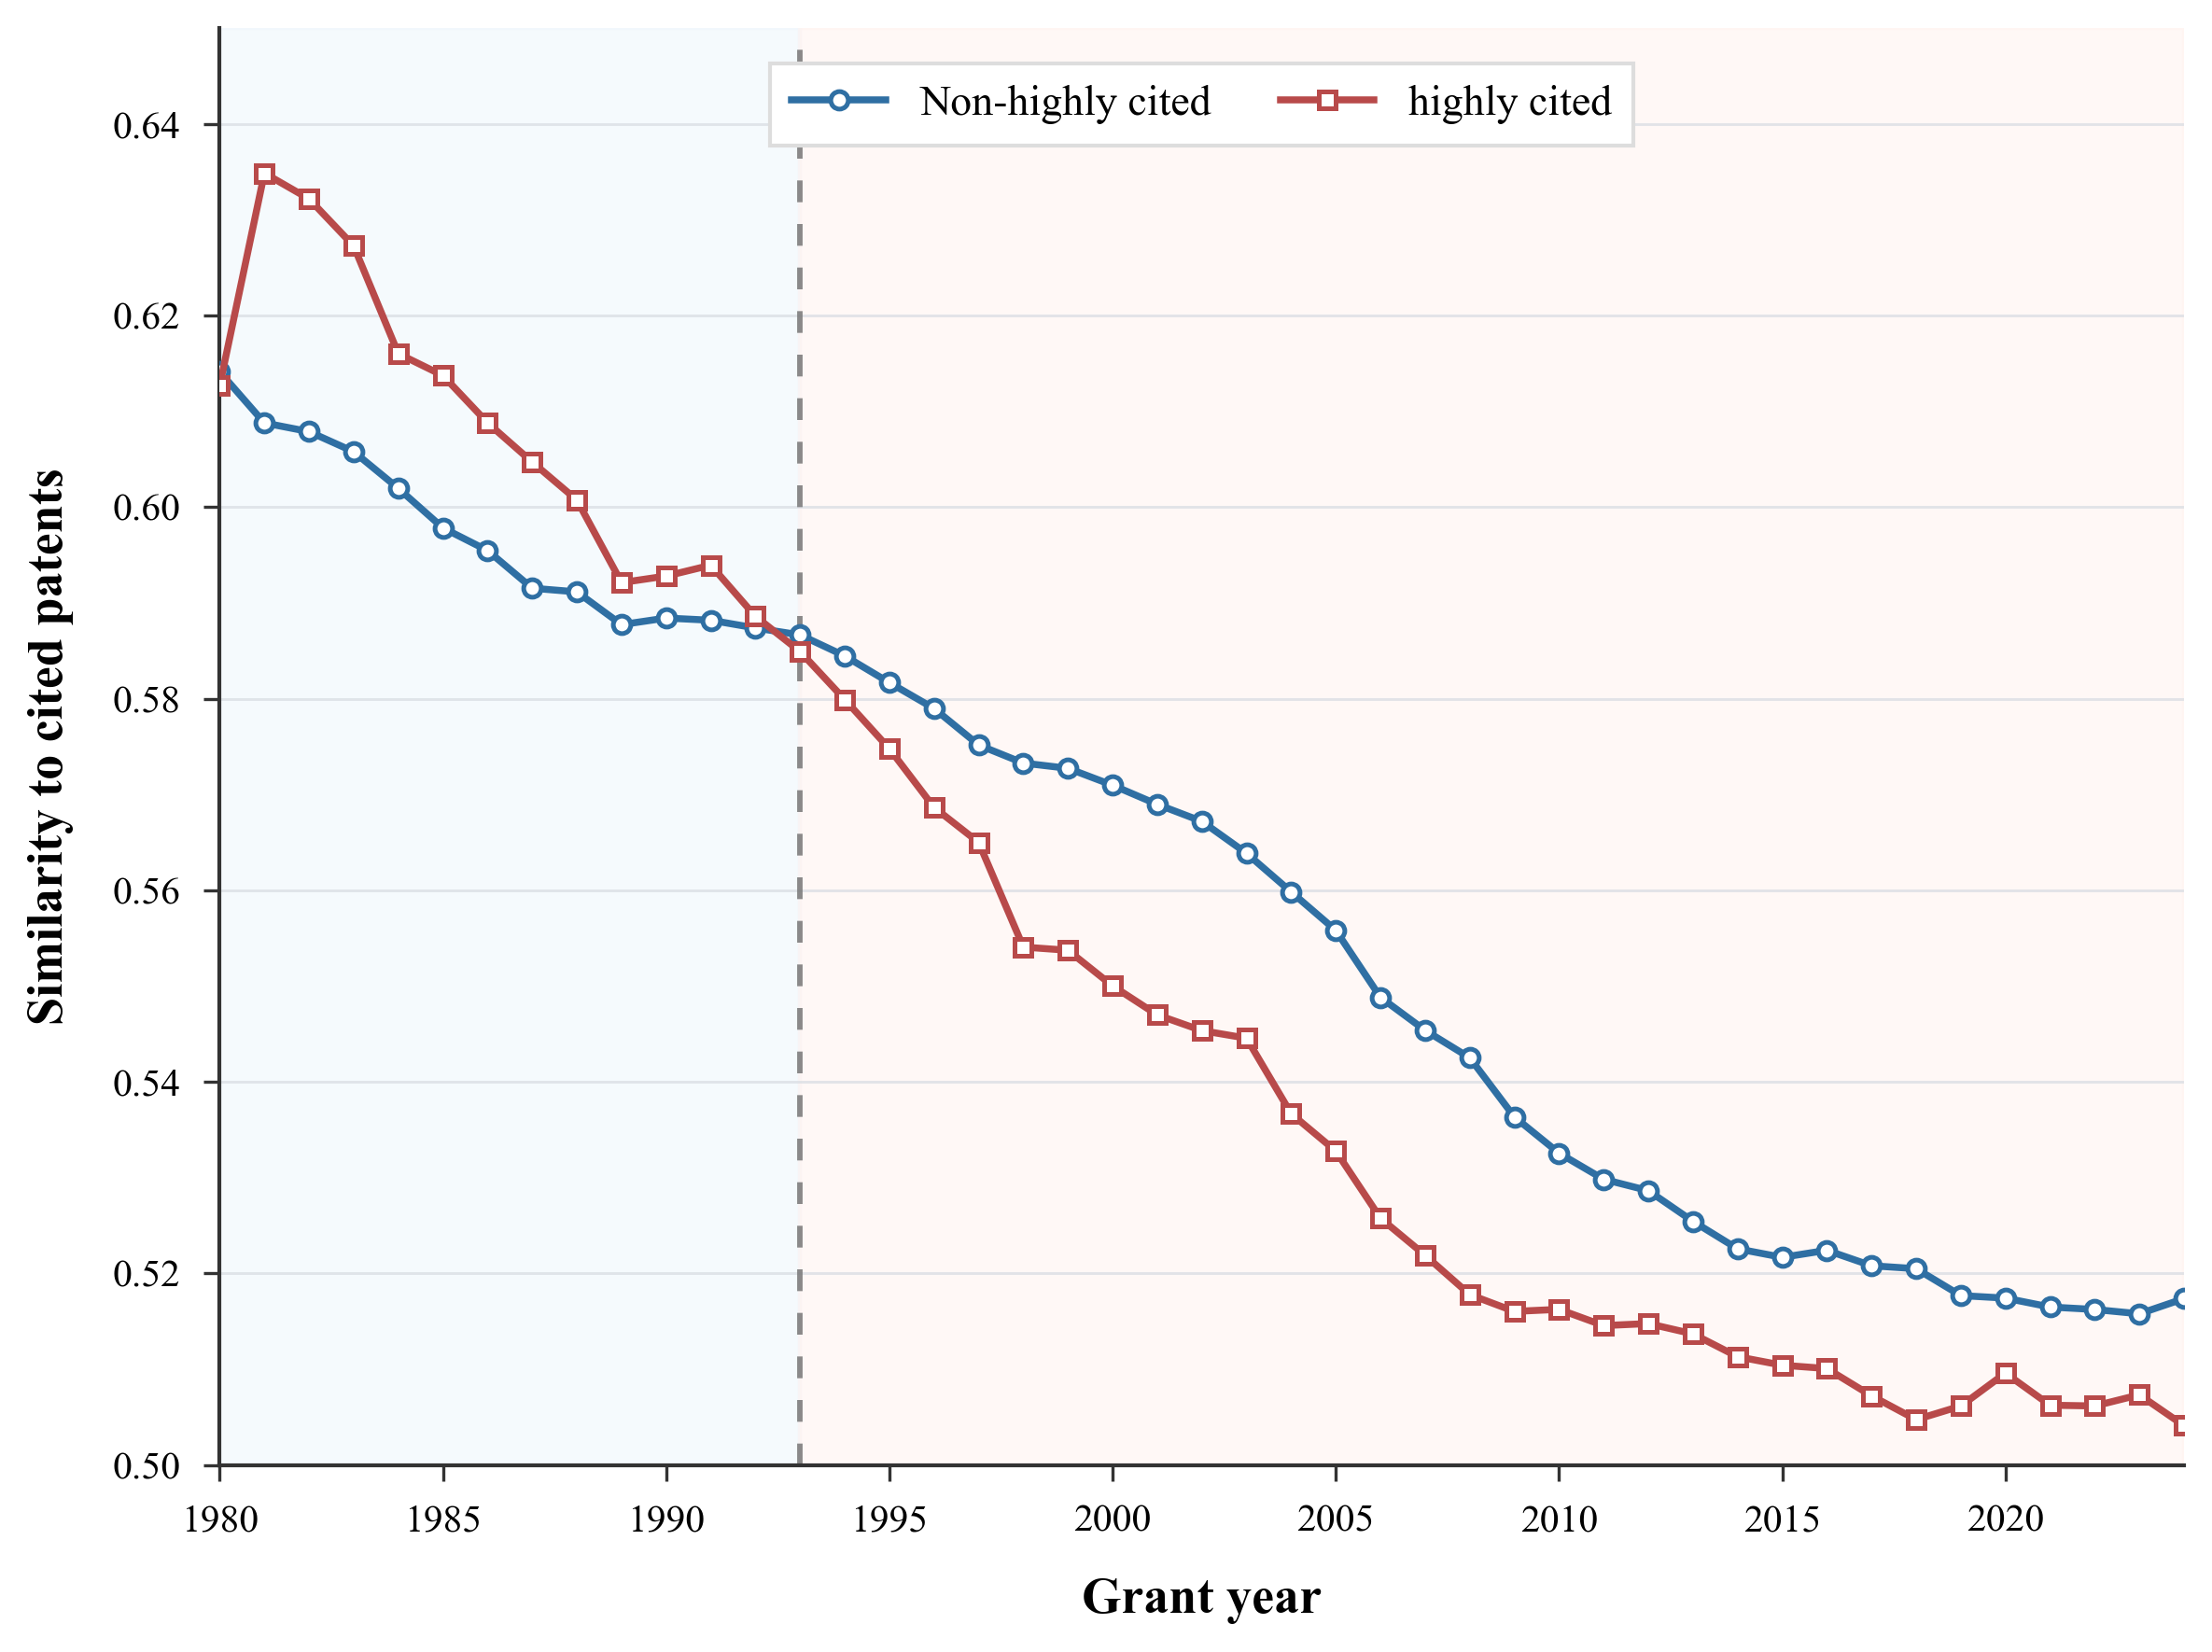

In [40]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# 颜色设定：低饱和、论文图更耐看
blue = '#2F6FA3'
red = '#B84A4A'
pre_bg = '#EEF6FC'
post_bg = '#FFF3F0'
grid_color = '#D9DDE3'
spine_color = '#333333'

# 背景分区：比 fill_between 更稳定，不受 y 轴范围影响
ax.axvspan(
    year_sim.index.min(), 1993,
    color=pre_bg,
    alpha=0.55,
    zorder=0
)

ax.axvspan(
    1993, year_sim.index.max(),
    color=post_bg,
    alpha=0.55,
    zorder=0
)

# 1993 年分界线
ax.axvline(
    x=1993,
    color='#777777',
    linestyle=(0, (4, 4)),
    linewidth=1.4,
    alpha=0.85,
    zorder=2
)

# 折线：白心 marker 会更干净，也能避免红蓝点过重
ax.plot(
    year_sim.index,
    year_sim['non-top'],
    color=blue,
    marker='o',
    markerfacecolor='white',
    markeredgecolor=blue,
    markeredgewidth=1.2,
    lw=1.8,
    ms=4.5,
    label='Non-highly cited',
    zorder=4
)

ax.plot(
    year_sim.index,
    year_sim['top'],
    color=red,
    marker='s',
    markerfacecolor='white',
    markeredgecolor=red,
    markeredgewidth=1.2,
    lw=1.8,
    ms=4.5,
    label='highly cited',
    zorder=4
)

# 字体不变
ax.set_xlabel('Grant year', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Similarity to cited patents', fontsize=13, fontweight='bold', labelpad=10)

# 网格：只保留横向，更像论文图
ax.grid(
    axis='y',
    color=grid_color,
    linestyle='-',
    linewidth=0.7,
    alpha=0.75,
    zorder=1
)

# 边框优化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['left'].set_color(spine_color)
ax.spines['bottom'].set_color(spine_color)

# 刻度不改字体大小
ax.tick_params(axis='x', labelsize=10, pad=6, length=4, width=0.8, color=spine_color)
ax.tick_params(axis='y', labelsize=10, pad=6, length=4, width=0.8, color=spine_color)

# 坐标范围
ax.set_ylim(0.5, 0.65)
ax.set_xlim(year_sim.index.min(), year_sim.index.max())

# 图例：更轻、更干净
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    fontsize=11,
    frameon=True,
    fancybox=False,
    framealpha=1,
    edgecolor='#DDDDDD',
    facecolor='white',
    handlelength=2.2,
    columnspacing=1.6,
    borderpad=0.5
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

plt.close('all')

In [29]:
# 1) 先对 sim 做聚合
sim_stats = (
    p2psim_top
    .groupby('citing_id')['sim']
    .agg(['max', 'min','mean', 'std'])
    .rename(columns={'max': 'sim_max',
                    'min':'sim_min',
                     'mean': 'sim_mean',
                     'std': 'sim_std',})
    .assign(sim_cv=lambda x: x['sim_std'] / x['sim_mean'])
)

In [31]:
sim_stats

,sim_max,sim_min,sim_mean,sim_std,sim_cv
citing_id,,,,,
4180867,0.453,0.453,0.453000,NaN,NaN
4180868,0.598,0.554,0.571667,0.023245,0.040662
4180870,0.462,0.462,0.462000,NaN,NaN
4180871,0.694,0.548,0.615667,0.073582,0.119516
4180875,0.680,0.653,0.670000,0.014799,0.022088
...,...,...,...,...,...
RE31699,0.726,0.557,0.637667,0.084760,0.132923
RE31700,0.647,0.647,0.647000,NaN,NaN
RE31701,0.733,0.733,0.733000,NaN,NaN


In [32]:
# 按 citing_id 分组，把 is_top 求和，并重置索引
citing_top_cnt = (
    p2psim_top.groupby('citing_id', as_index=False)['is_top']
              .sum()
              .rename(columns={'is_top': 'top_sum'})
)

In [33]:
# 可以先取每个 citing_id 的第一行，再合并 top_sum：
other_cols = ['patent_year', 'num_claims', 'cites_5yr']  # 按需增删
summary = (
    p2psim_top.drop_duplicates(subset=['citing_id'], keep='first')
              .drop(columns=['is_top'])           # 去掉旧的 is_top
              .merge(citing_top_cnt, on='citing_id', how='left')
)

In [34]:
summary

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,top_sum
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0,0
1,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0,0
2,4617207,10000002,0.581,cited by examiner,10000002,2018.0,0.0,0
3,4342799,10000003,0.571,cited by applicant,10000003,2018.0,2.0,0
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
6960032,4005621,RE31699,0.557,NaN,RE31699,1984.0,0.0,0
6960033,4121599,RE31700,0.647,NaN,RE31700,1984.0,0.0,0
6960034,4057452,RE31701,0.733,NaN,RE31701,1984.0,0.0,0
6960035,3980511,RE34357,0.441,NaN,RE34357,1993.0,0.0,0


In [35]:
# 2) 合并到 summary
summary = summary.merge(sim_stats, on='citing_id', how='left')

In [36]:
summary_top = summary[summary['top_sum']>0]
summary_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,top_sum,sim_max,sim_min,sim_mean,sim_std,sim_cv
9,7250238,10000010,0.294,cited by applicant,10000010,2018.0,0.0,1,0.677,0.294,0.498000,0.135847,0.272784
10,5182056,10000011,0.503,cited by applicant,10000011,2018.0,6.0,4,0.585,0.321,0.483821,0.065189,0.134737
11,6322901,10000015,0.433,cited by applicant,10000015,2018.0,0.0,3,0.487,0.433,0.461667,0.027154,0.058817
18,4849910,10000023,0.435,cited by applicant,10000023,2018.0,18.0,1,0.732,0.362,0.602400,0.090314,0.149924
22,3950584,10000028,0.602,cited by examiner,10000028,2018.0,1.0,1,0.732,0.272,0.519433,0.090782,0.174772
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6959967,3967991,9975687,0.530,cited by applicant,9975687,2018.0,0.0,1,0.672,0.147,0.426598,0.116726,0.273622
6959969,4623074,9975689,0.437,cited by applicant,9975689,2018.0,1.0,2,0.996,0.266,0.474154,0.149546,0.315396
6959979,4408676,9975701,0.530,cited by applicant,9975701,2018.0,1.0,1,0.783,0.526,0.636583,0.080821,0.126961
6960005,3939978,9975728,0.402,cited by applicant,9975728,2018.0,1.0,1,0.693,0.186,0.501421,0.106884,0.213161


##### 整体相似度变化

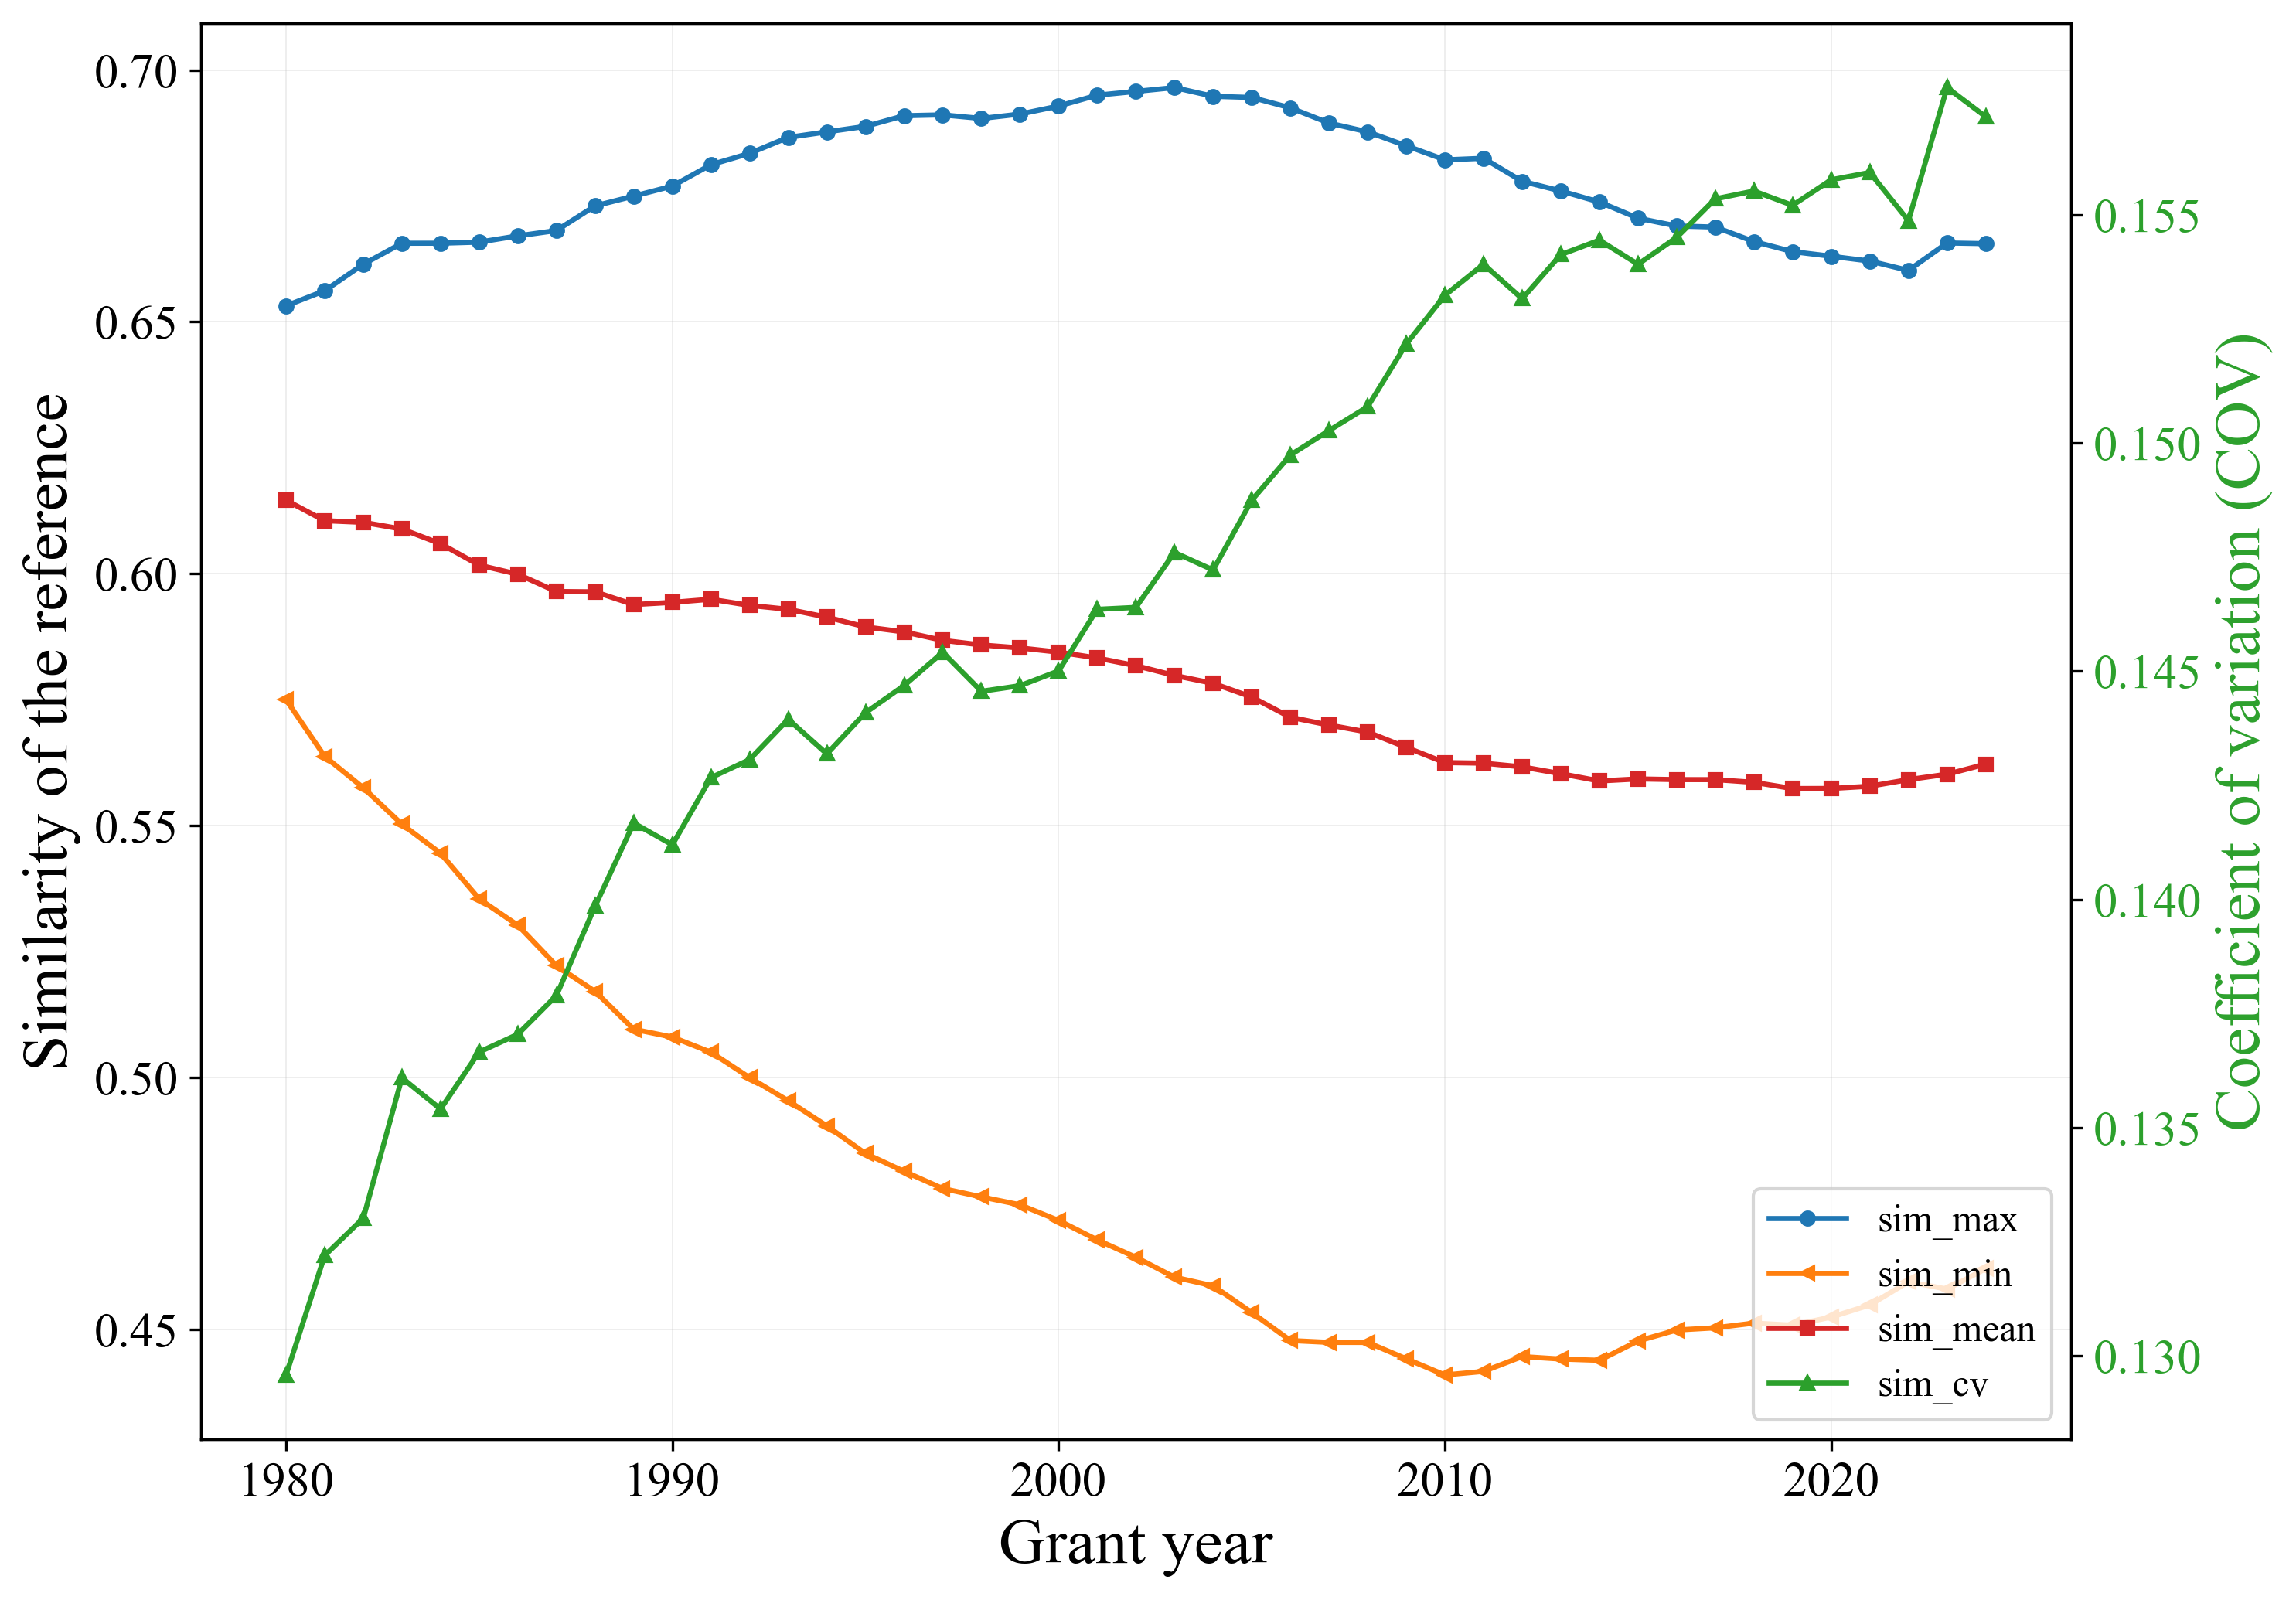

In [37]:
# 1) 数据准备（保持不变）
cols = ['sim_max', 'sim_min', 'sim_mean', 'sim_cv']
year_stats = (
    summary
    .query("1980 <= patent_year <= 2024")
    .groupby('patent_year')[cols]
    .mean()
    .dropna(how='all')
    .sort_index()
)

# ------------------------------------------------------------------
# 2) 柔和调色盘（主坐标轴 3 色 + 副坐标轴 1 色）
colors = {
    'sim_max':  '#1f77b4',   # 柔和蓝
    'sim_min':  '#ff7f0e',   # 柔和橙
    'sim_mean': '#d62728',   # 柔和红
    'sim_cv':   '#2ca02c'    # 柔和绿
}

# ------------------------------------------------------------------
# 3) 绘图
fig, ax1 = plt.subplots(figsize=(10, 7), dpi=300)

# 主坐标轴
for col, marker in [('sim_max', 'o'), ('sim_min', '<'), ('sim_mean', 's')]:
    ax1.plot(year_stats.index, year_stats[col],
             color=colors[col], marker=marker,
             lw=1.6, ms=4, label=col)

ax1.set_xlabel('Grant year')
ax1.set_ylabel('Similarity of the reference')
ax1.grid(alpha=0.25, lw=0.4)

# 副坐标轴
ax2 = ax1.twinx()
ax2.plot(year_stats.index, year_stats['sim_cv'],
         color=colors['sim_cv'], marker='^',
         lw=1.6, ms=4, label='sim_cv')
ax2.set_ylabel('Coefficient of variation (COV)', color=colors['sim_cv'])
ax2.tick_params(axis='y', labelcolor=colors['sim_cv'])

# 统一图例（放在图内右上角，不遮挡曲线）
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='lower right', frameon=True, fancybox=True, shadow=False,fontsize=12)

# 细边 & 紧凑布局
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

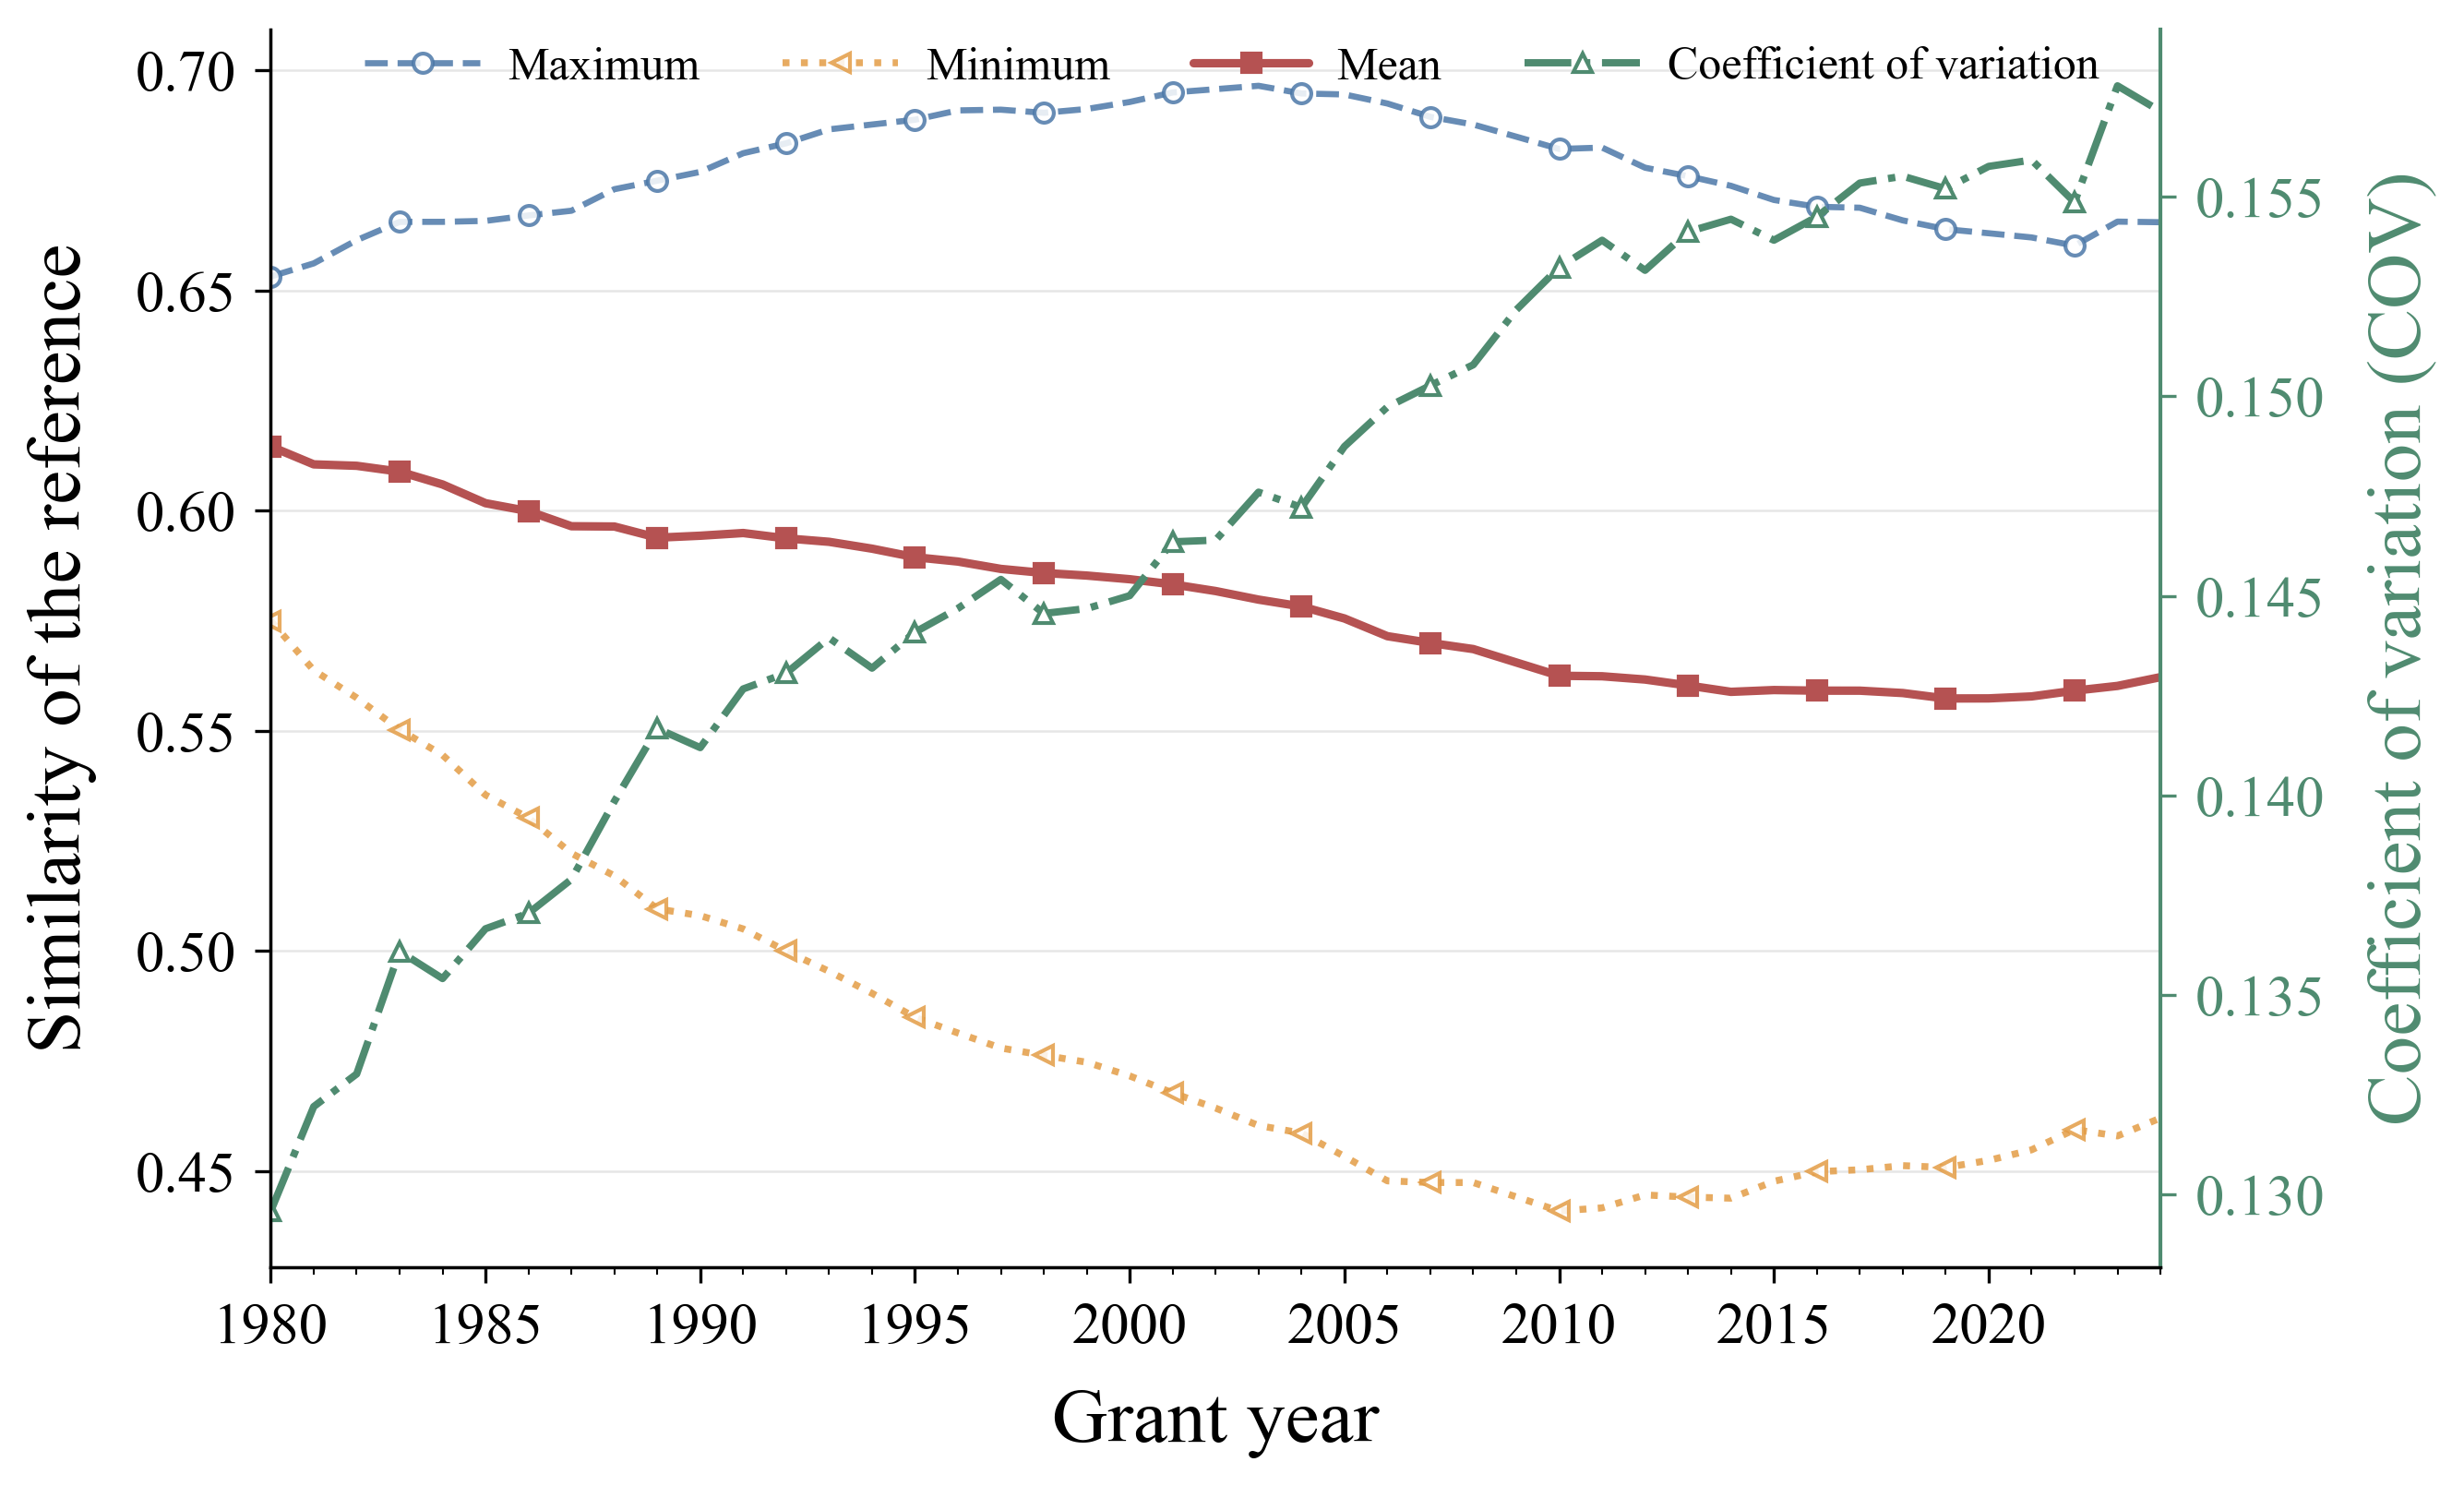

In [41]:
from matplotlib.ticker import MultipleLocator

# ------------------------------------------------------------------
# 2) 更克制的论文配色
colors = {
    'sim_max':  '#4C78A8',   # 柔和蓝
    'sim_min':  '#E39C45',   # 柔和橙
    'sim_mean': '#B55252',   # 暗红，突出均值
    'sim_cv':   '#4F8B70'    # 灰绿色
}

labels = {
    'sim_max':  'Maximum',
    'sim_min':  'Minimum',
    'sim_mean': 'Mean',
    'sim_cv':   'Coefficient of variation'
}

# 每条曲线仅显示约 12 个标记，避免过密
mark_every = max(len(year_stats) // 12, 1)

# ------------------------------------------------------------------
# 3) 绘图
fig, ax1 = plt.subplots(figsize=(9, 6), dpi=300)

line_specs = {
    'sim_max':  dict(marker='o', linestyle='--', lw=1.6, alpha=0.85),
    'sim_min':  dict(marker='<', linestyle=':',  lw=1.8, alpha=0.85),
    'sim_mean': dict(marker='s', linestyle='-',  lw=2.2, alpha=1.00)
}

# 主坐标轴
for col, spec in line_specs.items():
    ax1.plot(
        year_stats.index,
        year_stats[col],
        color=colors[col],
        label=labels[col],
        markevery=mark_every,
        ms=5,
        markerfacecolor='white' if col != 'sim_mean' else colors[col],
        markeredgecolor=colors[col],
        markeredgewidth=1.0,
        solid_capstyle='round',
        zorder=3 if col == 'sim_mean' else 2,
        **spec
    )

ax1.set_xlabel('Grant year', labelpad=9)
ax1.set_ylabel('Similarity of the reference', labelpad=10)

ax1.set_xlim(year_stats.index.min(), year_stats.index.max())
ax1.margins(x=0.01)

# 年份刻度：每 5 年一个主刻度，每年一个短刻度
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_minor_locator(MultipleLocator(1))

ax1.tick_params(axis='both', which='major',
                direction='out', length=4, width=0.8, pad=5)
ax1.tick_params(axis='x', which='minor',
                direction='out', length=2, width=0.5)

# 只保留横向网格，降低视觉干扰
ax1.grid(
    axis='y',
    color='#D9D9D9',
    linestyle='-',
    linewidth=0.6,
    alpha=0.65
)
ax1.set_axisbelow(True)

# ------------------------------------------------------------------
# 副坐标轴
ax2 = ax1.twinx()

ax2.plot(
    year_stats.index,
    year_stats['sim_cv'],
    color=colors['sim_cv'],
    marker='^',
    linestyle='-.',
    lw=1.9,
    ms=5,
    markevery=mark_every,
    markerfacecolor='white',
    markeredgecolor=colors['sim_cv'],
    markeredgewidth=1.0,
    label=labels['sim_cv'],
    solid_capstyle='round',
    zorder=2
)

ax2.set_ylabel(
    'Coefficient of variation (COV)',
    color=colors['sim_cv'],
    labelpad=11
)
ax2.tick_params(
    axis='y',
    colors=colors['sim_cv'],
    direction='out',
    length=4,
    width=0.8,
    pad=5
)

# ------------------------------------------------------------------
# 边框处理
for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)

ax1.spines['right'].set_visible(False)

for spine in ['left', 'bottom']:
    ax1.spines[spine].set_color('#4D4D4D')
    ax1.spines[spine].set_linewidth(0.8)

ax2.spines['right'].set_color(colors['sim_cv'])
ax2.spines['right'].set_linewidth(1.0)

# ------------------------------------------------------------------
# 统一图例：置于图形上方，避免遮挡数据
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.9),
    ncol=4,
    frameon=False,
    fontsize=12,
    handlelength=2.5,
    columnspacing=1.8,
    handletextpad=0.6
)

# 为顶部图例预留空间
fig.tight_layout(rect=[0, 0, 1, 0.91])

plt.show()

In [56]:
summary.to_csv('./citations_result/stata_summary.csv',index=False)

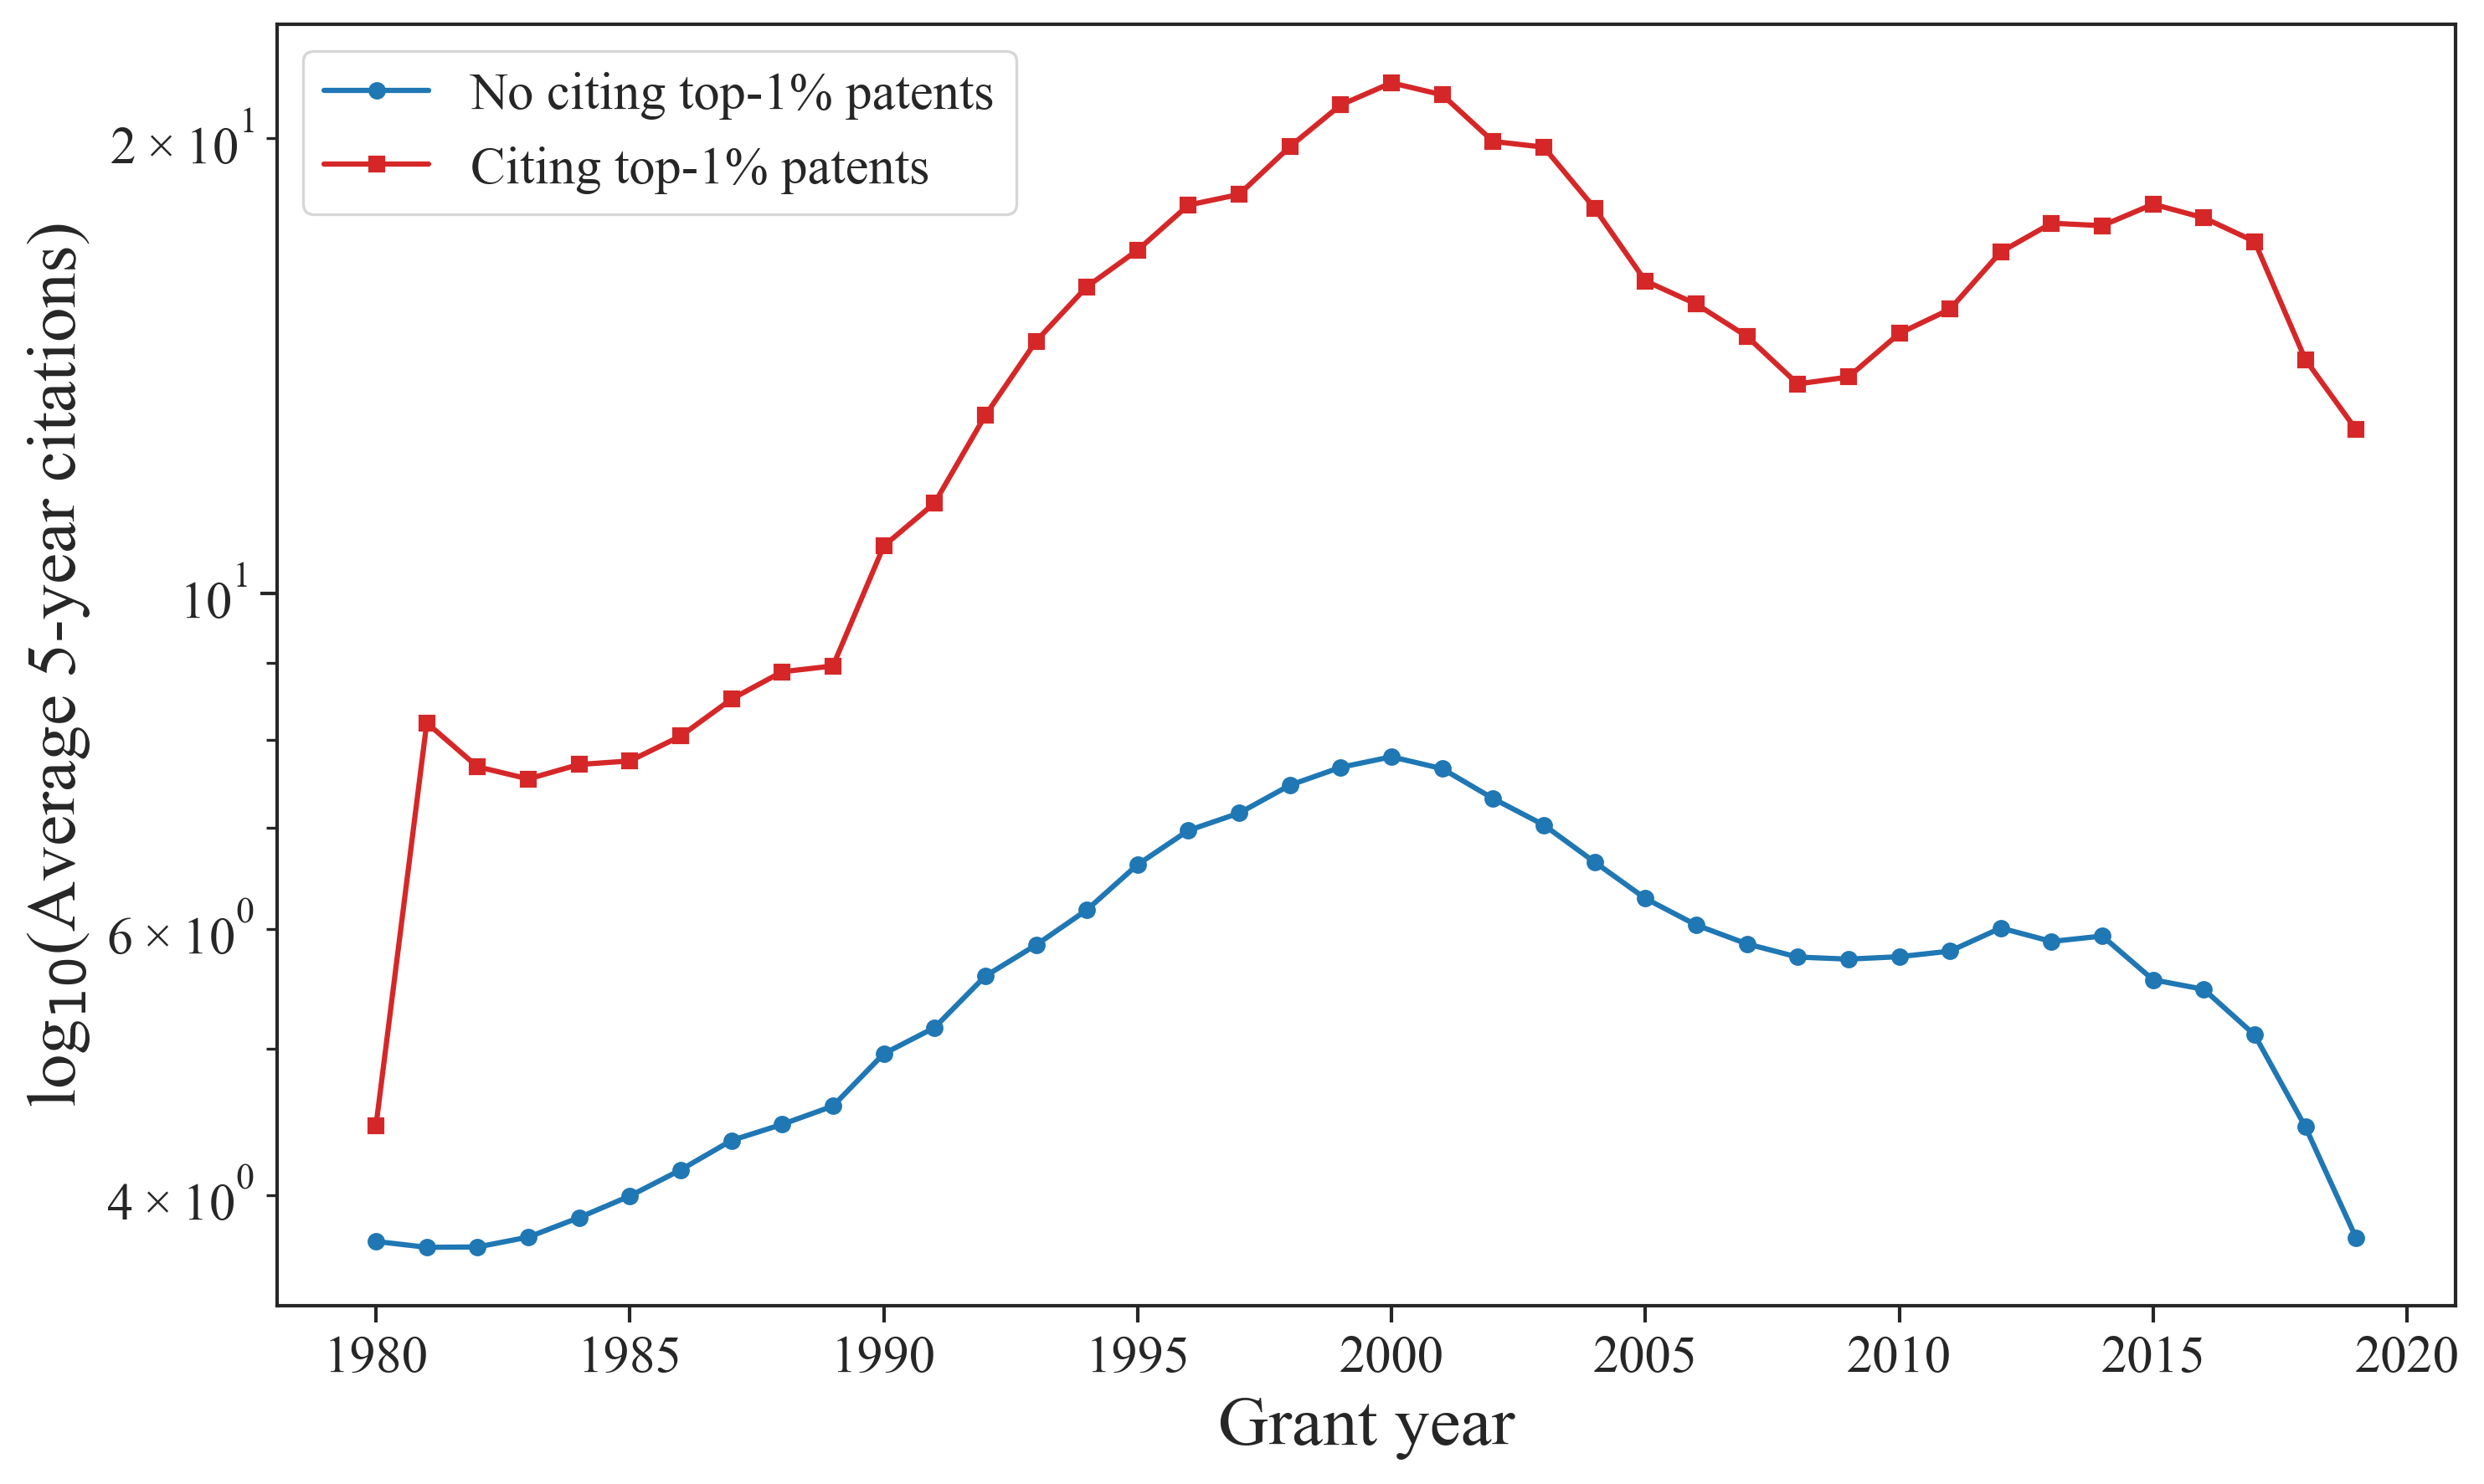

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) 未引用 top1% 的专利
c1 = (
    summary
    .query("1980 <= patent_year <= 2019")
    .query("top_sum == 0")                       # 只保留 top_sum==0
    .assign(cites_5yr=lambda x: np.where(x['cites_5yr'] == 0, np.nan, x['cites_5yr']))
    .groupby('patent_year')['cites_5yr']
    .mean()
    .dropna()
    .sort_index()
)

# 2) 至少引用过 1 篇 top1% 的专利
c2 = (
    summary
    .query("1980 <= patent_year <= 2019")
    .query("top_sum > 0")                        # 只保留 top_sum>0
    .assign(cites_5yr=lambda x: np.where(x['cites_5yr'] == 0, np.nan, x['cites_5yr']))
    .groupby('patent_year')['cites_5yr']
    .mean()
    .dropna()
    .sort_index()
)

# --------------------------------------------------
# 3) 画两条折线（纵坐标对数）
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(c1.index, c1.values, marker='o', label='No citing top-1% patents', color='#1f77b4', lw=1.5, ms=4)
plt.plot(c2.index, c2.values, marker='s', label='Citing top-1% patents', color='#d62728', lw=1.5, ms=4)

plt.xlabel('Grant year')
plt.ylabel('log$_{10}$(Average 5-year citations)')
# plt.title('Average 5-year citations (1980–2019, log scale)')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

#### Step 6 分析引用top专利的特点

In [58]:
p2psim_top.head()

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,11.0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,11.0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,0.0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,0.0,0


In [59]:
p2psim_top_reference = p2psim_top[p2psim_top['is_top']>0]
p2psim_top_reference.head()

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
103,8488994,10000010,0.677,cited by examiner,10000010,2018.0,0.0,1
109,5204055,10000011,0.470,cited by applicant,10000011,2018.0,6.0,1
130,9149988,10000011,0.464,cited by applicant,10000011,2018.0,6.0,1
131,9370896,10000011,0.503,cited by applicant,10000011,2018.0,6.0,1
133,9815118,10000011,0.471,cited by examiner,10000011,2018.0,6.0,1


In [60]:
# 1) 先对 sim 做聚合
sim_stats_ = (
    p2psim_top_reference
    .groupby('citing_id')['sim']
    .agg(['max', 'min','mean', 'std'])
    .rename(columns={'max': 'sim_max',
                    'min':'sim_min',
                     'mean': 'sim_mean',
                     'std': 'sim_std',})
    .assign(sim_cv=lambda x: x['sim_std'] / x['sim_mean'])
)

In [61]:
# 如果还想把其它列也保留（例如 patent_year, num_claims 等），
# 可以先取每个 citing_id 的第一行，再合并 top_sum：
other_cols = ['patent_year', 'num_claims', 'cites_5yr']  # 按需增删
summary = (
    p2psim_top_reference.drop_duplicates(subset=['citing_id'], keep='first')
              .drop(columns=['is_top'])           # 去掉旧的 is_top
              .merge(citing_top_cnt, on='citing_id', how='left')
)

In [62]:
# 2) 合并到 summary
summary_top = summary.merge(sim_stats_, on='citing_id', how='left')

In [93]:
summary_top.to_csv('./citations_result/temp.csv',index=False)

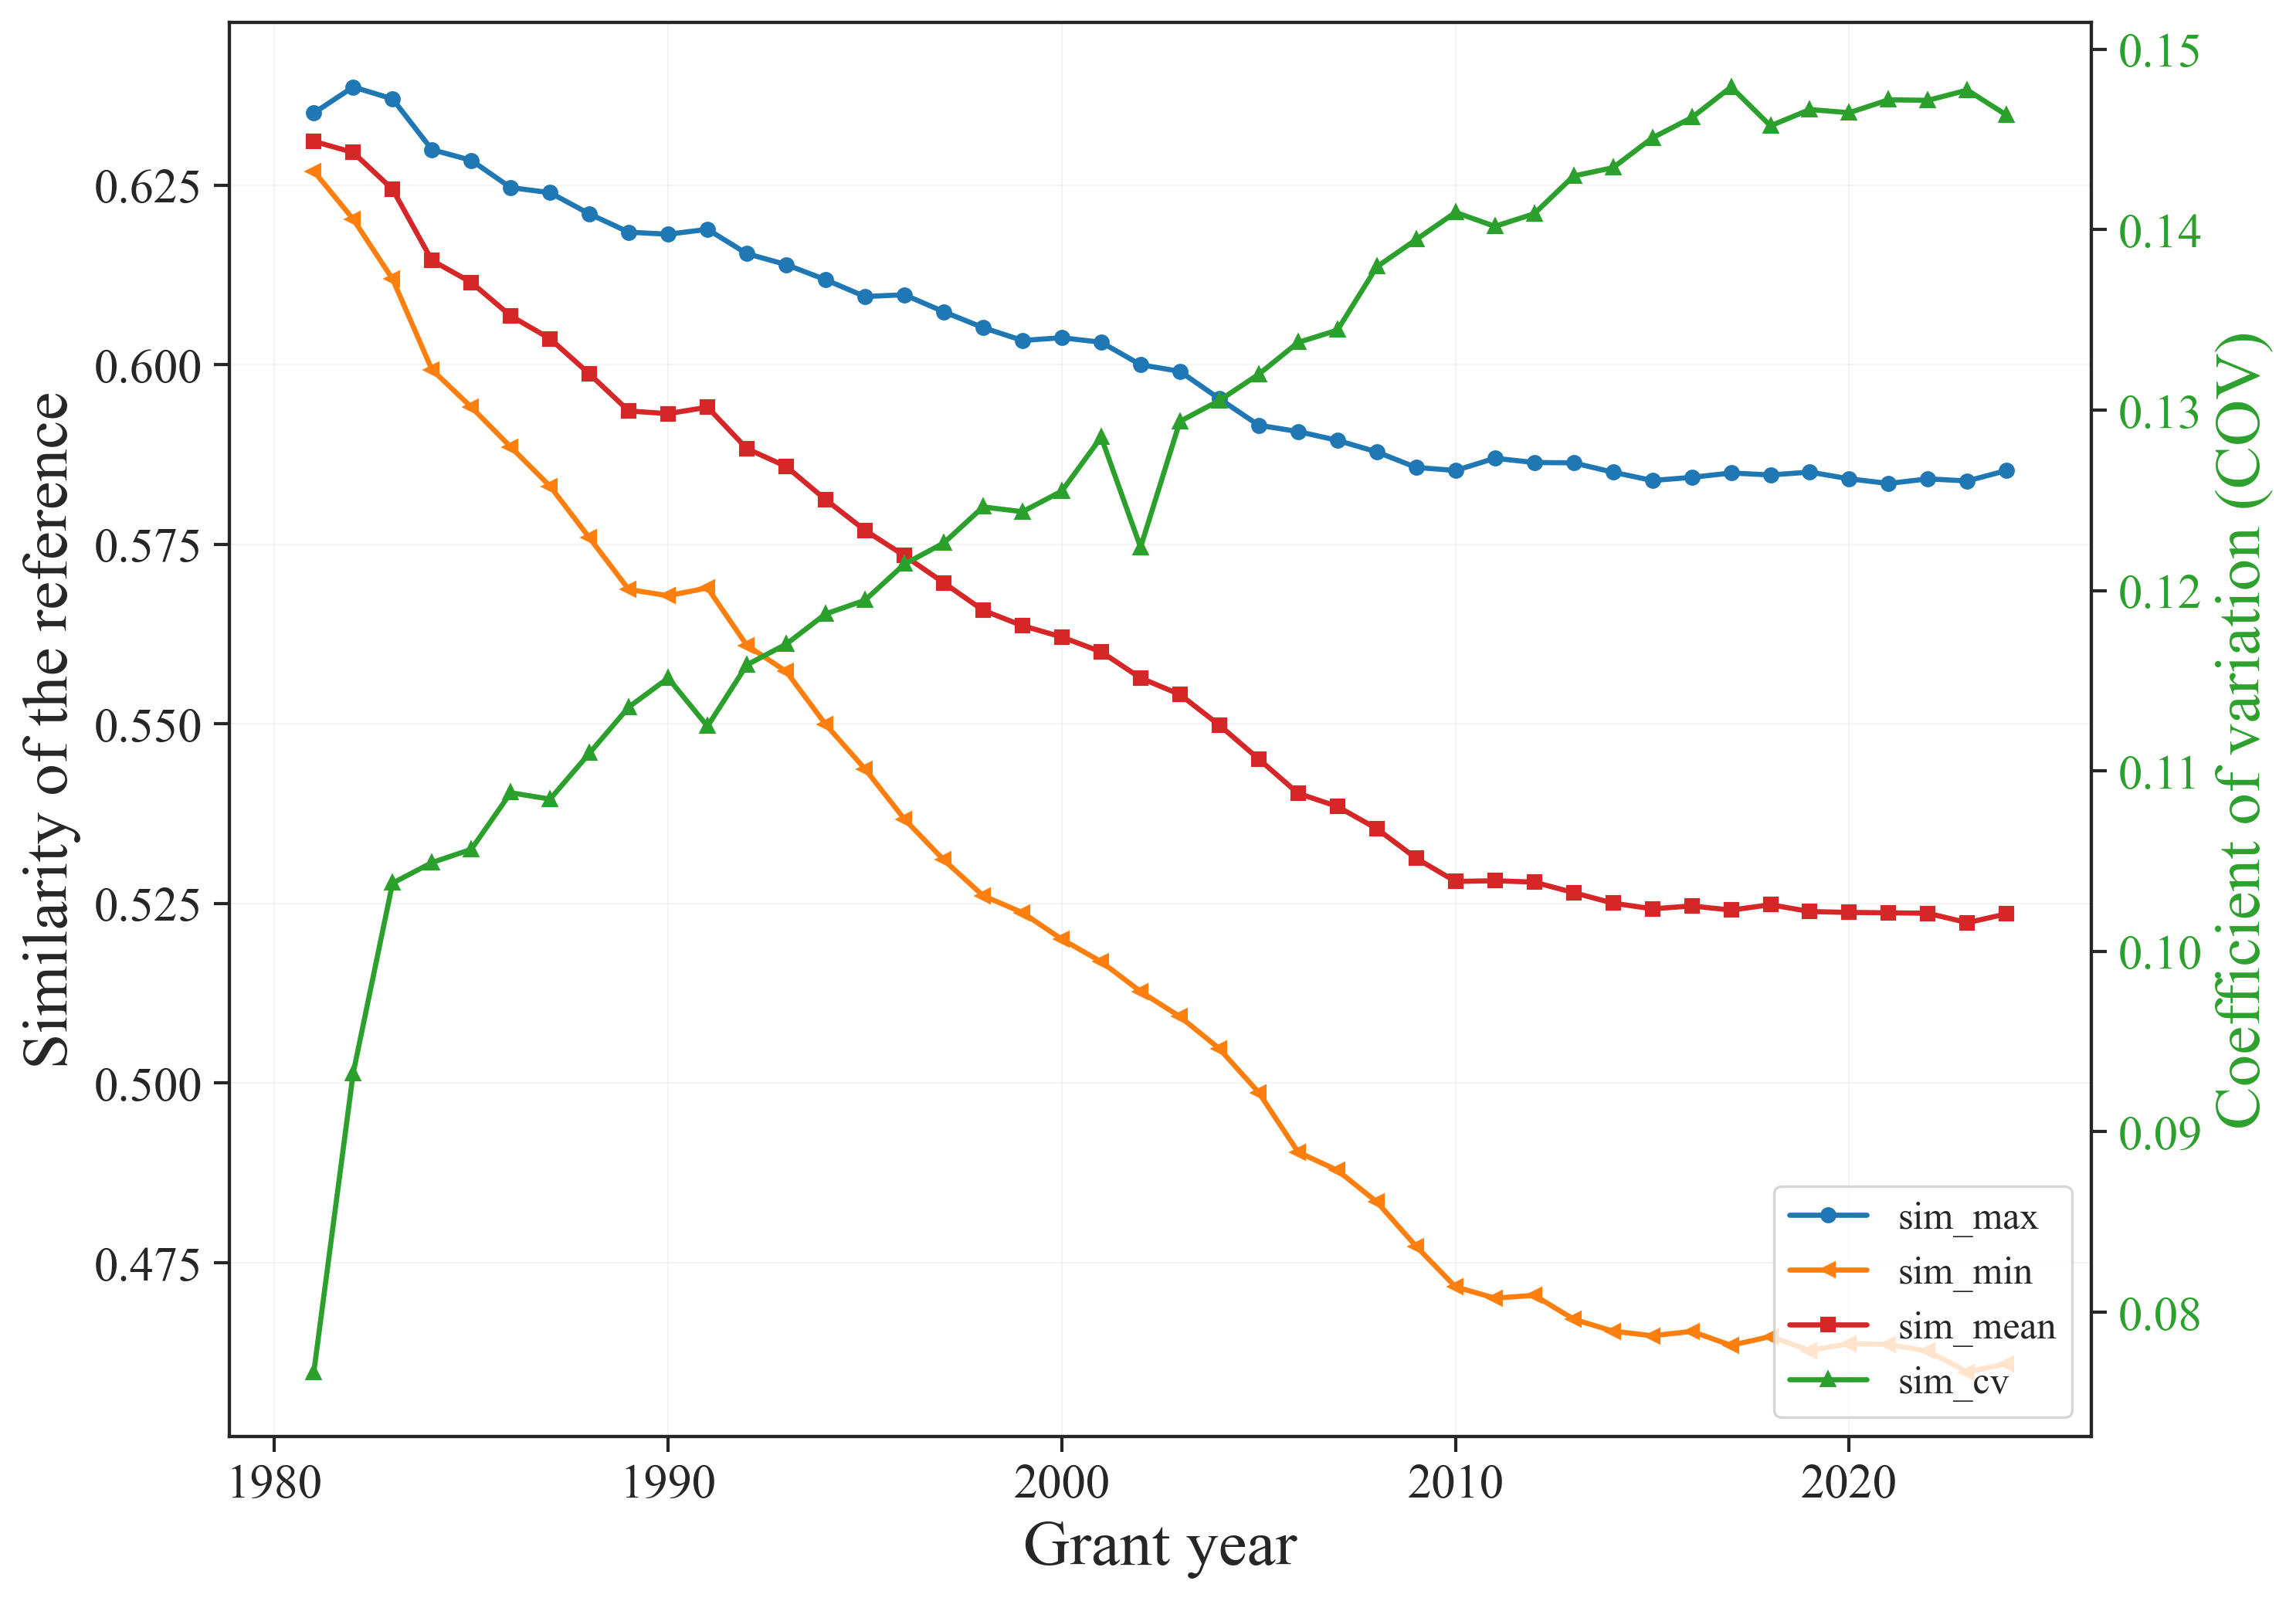

In [63]:
# 1) 数据准备（保持不变）
cols = ['sim_max', 'sim_min', 'sim_mean', 'sim_cv']
year_stats = (
    summary_top
    .query("1981 <= patent_year <= 2024")
    .groupby('patent_year')[cols]
    .mean()
    .dropna(how='all')
    .sort_index()
)

# ------------------------------------------------------------------
# 2) 柔和调色盘（主坐标轴 3 色 + 副坐标轴 1 色）
colors = {
    'sim_max':  '#1f77b4',   # 柔和蓝
    'sim_min':  '#ff7f0e',   # 柔和橙
    'sim_mean': '#d62728',   # 柔和红
    'sim_cv':   '#2ca02c'    # 柔和绿
}

# ------------------------------------------------------------------
# 3) 绘图
fig, ax1 = plt.subplots(figsize=(10, 7), dpi=300)

# 主坐标轴
for col, marker in [('sim_max', 'o'), ('sim_min', '<'), ('sim_mean', 's')]:
    ax1.plot(year_stats.index, year_stats[col],
             color=colors[col], marker=marker,
             lw=1.6, ms=4, label=col)

ax1.set_xlabel('Grant year')
ax1.set_ylabel('Similarity of the reference')
ax1.grid(alpha=0.25, lw=0.4)

# 副坐标轴
ax2 = ax1.twinx()
ax2.plot(year_stats.index, year_stats['sim_cv'],
         color=colors['sim_cv'], marker='^',
         lw=1.6, ms=4, label='sim_cv')
ax2.set_ylabel('Coefficient of variation (COV)', color=colors['sim_cv'])
ax2.tick_params(axis='y', labelcolor=colors['sim_cv'])

# 统一图例（放在图内右上角，不遮挡曲线）
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='lower right', frameon=True, fancybox=True, shadow=False,fontsize=12)

# 细边 & 紧凑布局
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

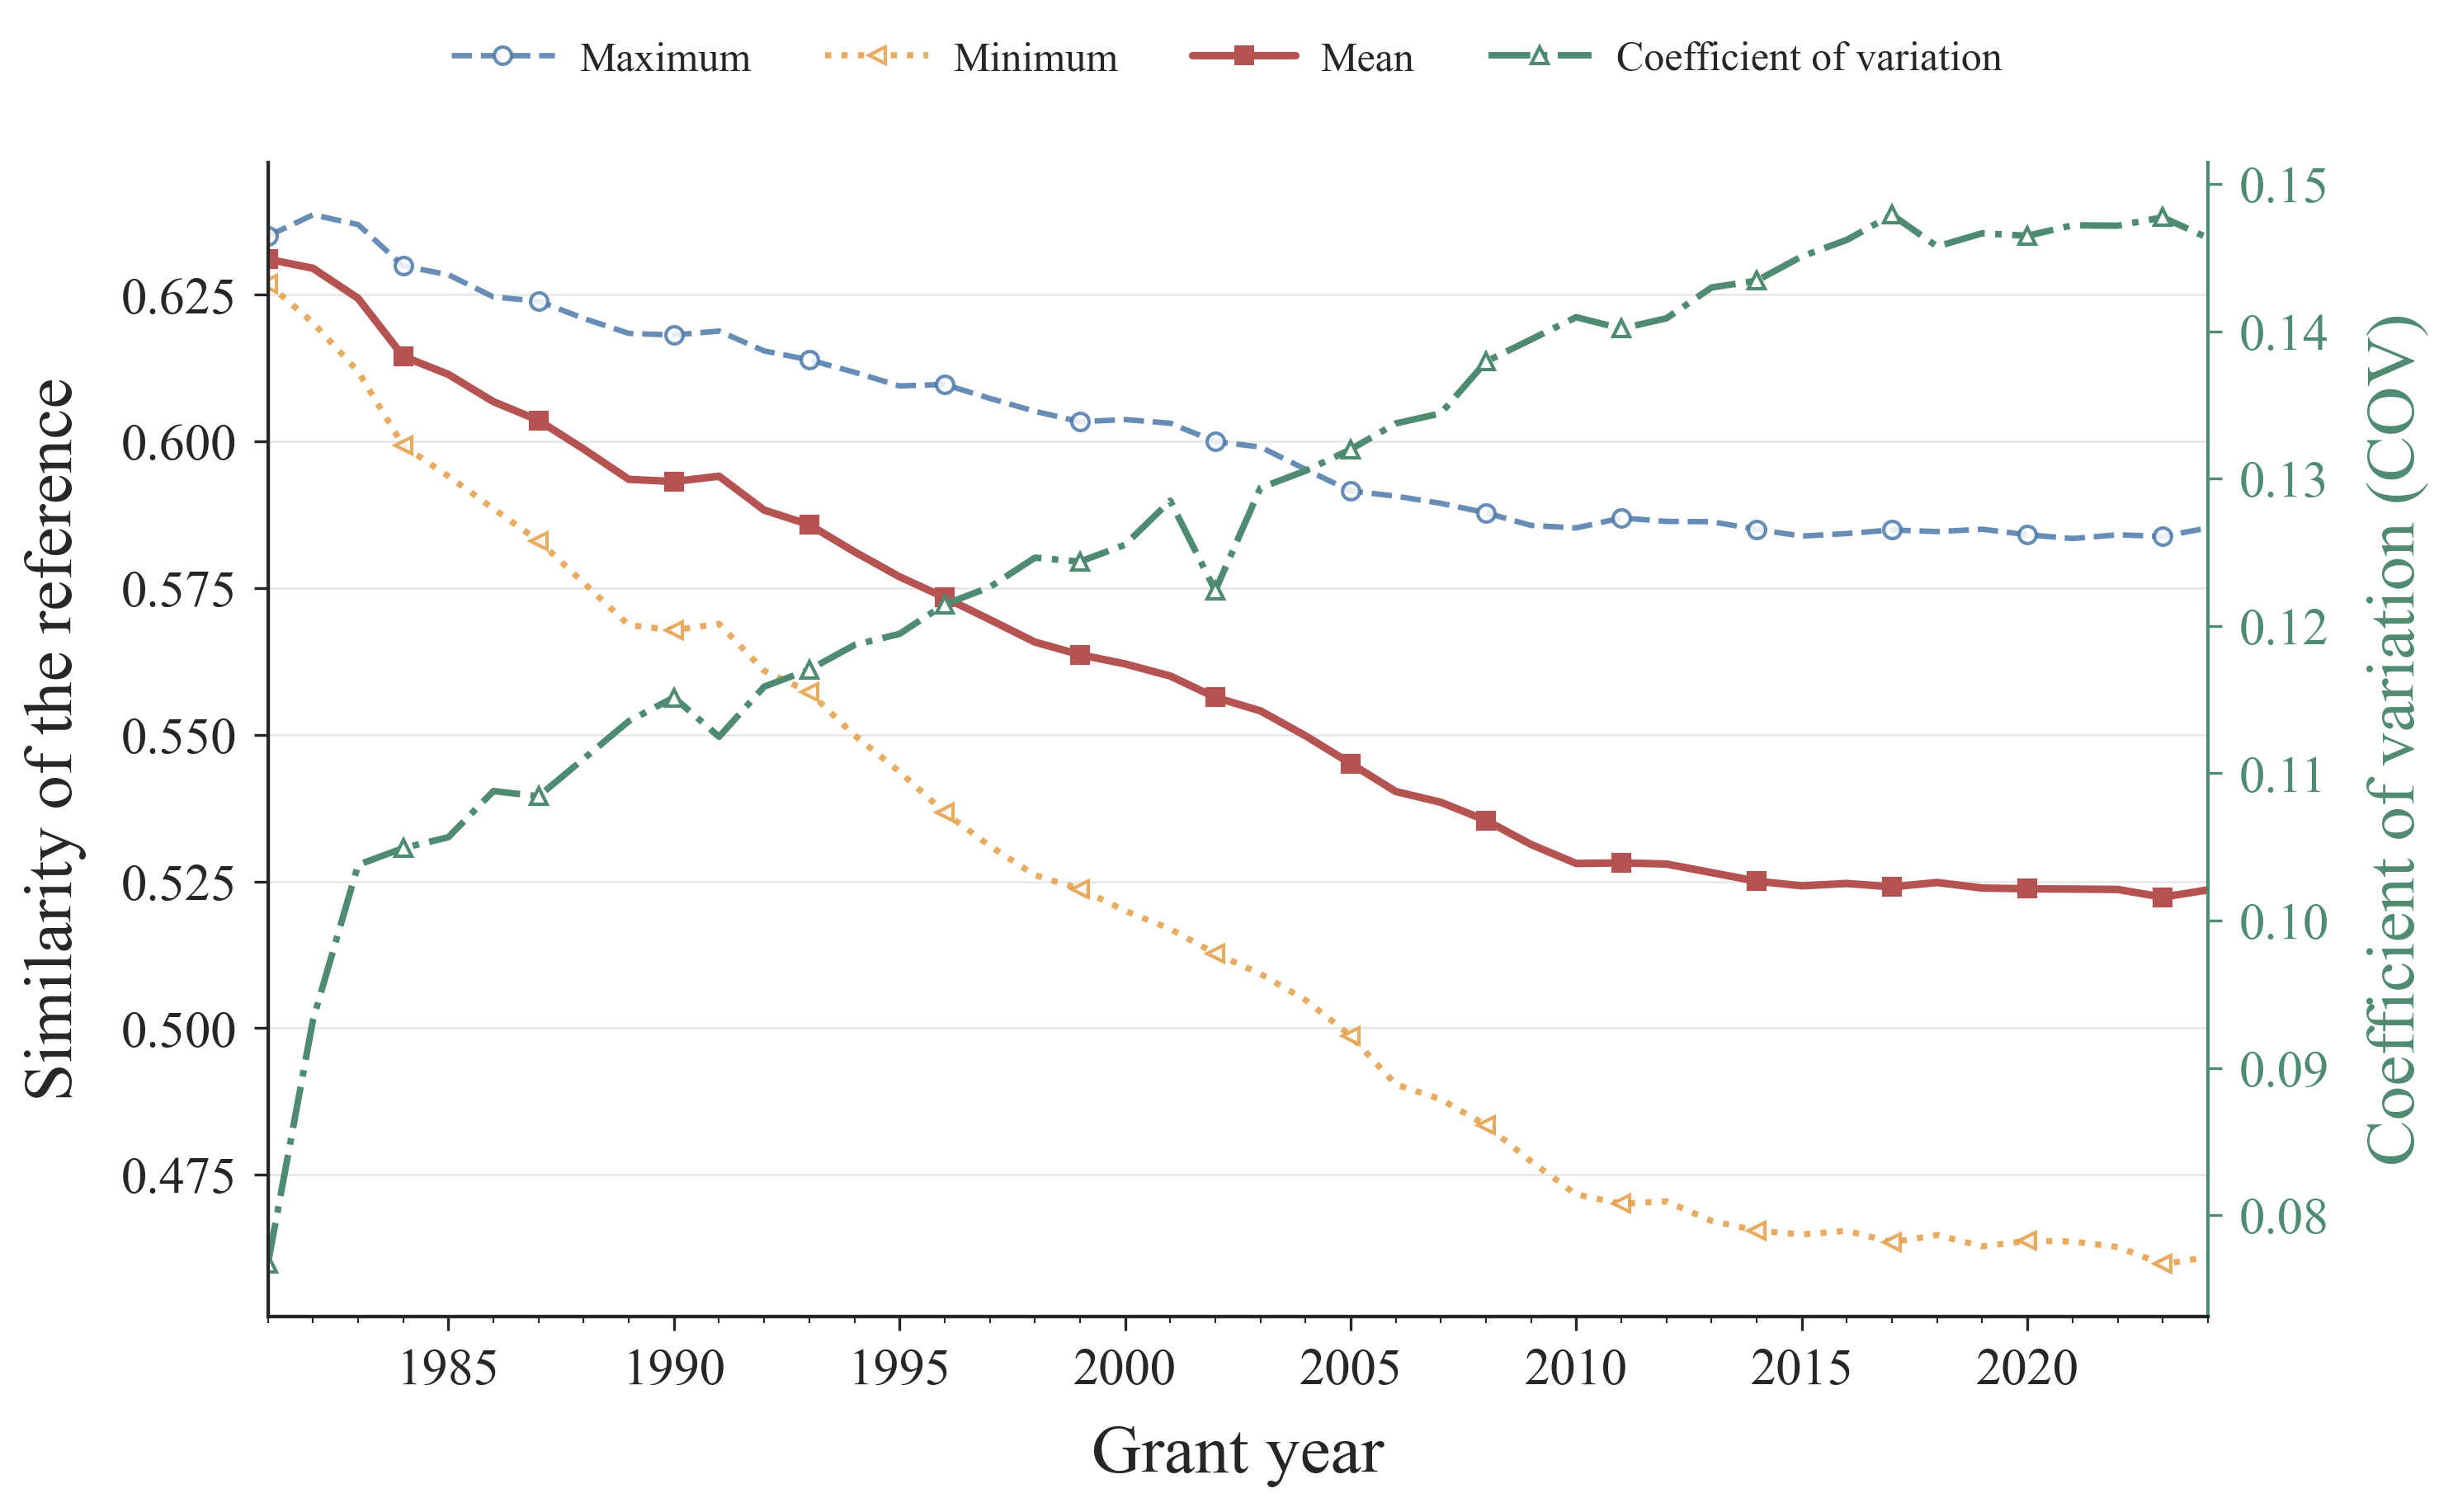

In [64]:
from matplotlib.ticker import MultipleLocator

# ------------------------------------------------------------------
# 2) 更克制的论文配色
colors = {
    'sim_max':  '#4C78A8',   # 柔和蓝
    'sim_min':  '#E39C45',   # 柔和橙
    'sim_mean': '#B55252',   # 暗红，突出均值
    'sim_cv':   '#4F8B70'    # 灰绿色
}

labels = {
    'sim_max':  'Maximum',
    'sim_min':  'Minimum',
    'sim_mean': 'Mean',
    'sim_cv':   'Coefficient of variation'
}

# 每条曲线仅显示约 12 个标记，避免过密
mark_every = max(len(year_stats) // 12, 1)

# ------------------------------------------------------------------
# 3) 绘图
fig, ax1 = plt.subplots(figsize=(10, 6.2), dpi=300)

line_specs = {
    'sim_max':  dict(marker='o', linestyle='--', lw=1.6, alpha=0.85),
    'sim_min':  dict(marker='<', linestyle=':',  lw=1.8, alpha=0.85),
    'sim_mean': dict(marker='s', linestyle='-',  lw=2.2, alpha=1.00)
}

# 主坐标轴
for col, spec in line_specs.items():
    ax1.plot(
        year_stats.index,
        year_stats[col],
        color=colors[col],
        label=labels[col],
        markevery=mark_every,
        ms=5,
        markerfacecolor='white' if col != 'sim_mean' else colors[col],
        markeredgecolor=colors[col],
        markeredgewidth=1.0,
        solid_capstyle='round',
        zorder=3 if col == 'sim_mean' else 2,
        **spec
    )

ax1.set_xlabel('Grant year', labelpad=9)
ax1.set_ylabel('Similarity of the reference', labelpad=10)

ax1.set_xlim(year_stats.index.min(), year_stats.index.max())
ax1.margins(x=0.01)

# 年份刻度：每 5 年一个主刻度，每年一个短刻度
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_minor_locator(MultipleLocator(1))

ax1.tick_params(axis='both', which='major',
                direction='out', length=4, width=0.8, pad=5)
ax1.tick_params(axis='x', which='minor',
                direction='out', length=2, width=0.5)

# 只保留横向网格，降低视觉干扰
ax1.grid(
    axis='y',
    color='#D9D9D9',
    linestyle='-',
    linewidth=0.6,
    alpha=0.65
)
ax1.set_axisbelow(True)

# ------------------------------------------------------------------
# 副坐标轴
ax2 = ax1.twinx()

ax2.plot(
    year_stats.index,
    year_stats['sim_cv'],
    color=colors['sim_cv'],
    marker='^',
    linestyle='-.',
    lw=1.9,
    ms=5,
    markevery=mark_every,
    markerfacecolor='white',
    markeredgecolor=colors['sim_cv'],
    markeredgewidth=1.0,
    label=labels['sim_cv'],
    solid_capstyle='round',
    zorder=2
)

ax2.set_ylabel(
    'Coefficient of variation (COV)',
    color=colors['sim_cv'],
    labelpad=11
)
ax2.tick_params(
    axis='y',
    colors=colors['sim_cv'],
    direction='out',
    length=4,
    width=0.8,
    pad=5
)

# ------------------------------------------------------------------
# 边框处理
for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)

ax1.spines['right'].set_visible(False)

for spine in ['left', 'bottom']:
    ax1.spines[spine].set_color('#4D4D4D')
    ax1.spines[spine].set_linewidth(0.8)

ax2.spines['right'].set_color(colors['sim_cv'])
ax2.spines['right'].set_linewidth(1.0)

# ------------------------------------------------------------------
# 统一图例：置于图形上方，避免遮挡数据
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=4,
    frameon=False,
    fontsize=12,
    handlelength=2.5,
    columnspacing=1.8,
    handletextpad=0.6
)

# 为顶部图例预留空间
fig.tight_layout(rect=[0, 0, 1, 0.91])

plt.show()

In [91]:
corr = summary_top[['cites_5yr', 'sim_cv']].corr().iloc[0, 1]
print(f"Pearson r = {corr:.4f}")

Pearson r = 0.0250


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------------
# 1) 取数 & 去掉 NaN
df = summary_top[['sim_mean', 'sim_cv']].dropna()

# ------------------------------------------------------------------
# 2) 计算二维核密度，用于颜色映射
xy = np.vstack([df['sim_mean'], df['sim_cv']])
kde  = gaussian_kde(xy)
z = kde(xy)

# ------------------------------------------------------------------
# 3) 绘图
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

# 散点，颜色 = 密度
sc = ax.scatter(df['sim_mean'], df['sim_cv'],
                c=z, s=15, cmap='turbo', alpha=0.9, rasterized=True)

# 可选：画 2D KDE 等高线，突出高密度区域
xi, yi = np.mgrid[df['sim_mean'].min():df['sim_mean'].max():100j,
                  df['sim_cv'].min():df['sim_cv'].max():100j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
ax.contour(xi, yi, zi, levels=4, colors='k', linewidths=0.4, alpha=0.4)

# ------------------------------------------------------------------
# 4) 美化
ax.set_xlabel('Mean similarity (sim_mean)')
ax.set_ylabel('Coefficient of variation (sim_cv)')
ax.grid(alpha=0.25)

# 颜色条
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Density')

plt.tight_layout()
plt.show()